### PubTator 3 + Europe PMC + MyGene/NCBI Gene + UniProt + Open Targets + STRING + Reactome + ChEMBL

In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv("all_pubmed_metadata_ifibio.csv", low_memory=False)

display(df.head(10))

print(df.columns)


,Unnamed: 0,PMID,DOI,PMCID,PII,Title,Abstract,AbstractSections,Authors,Keywords,...,PublicationDate,Grants,DataBanks,COIStatement,History,RelatedArticles,References,ArticleIDs,CitationStatus,IndexingMethod
0,0,42675027,10.1002/alz.71805,NaN,NaN,A strategic pathway for the ethical developmen...,Artificial intelligence (AI) is rapidly enteri...,"[{'Label': None, 'NlmCategory': None, 'Text': ...","[{'Position': 1, 'AuthorClean': 'Deaner N', 'L...","[{'Keyword': ""Alzheimer's disease"", 'Owner': '...",...,"{'Year': '2026', 'Month': 'Sep'}","[{'GrantID': None, 'Acronym': None, 'Agency': ...",[],NaN,"[{'Status': 'revised', 'Date': {'Year': '2026'...",[],"[{'Citation': ""2025 Alzheimer's disease facts ...","[{'Type': 'pubmed', 'Value': '42675027'}, {'Ty...",MEDLINE,Automated
1,1,42611393,10.1007/s12020-026-04746-w,NaN,10.1007/s12020-026-04746-w,Congenital goitrous hypothyroidism due to thyr...,PURPOSE: This study focused on elucidating the...,"[{'Label': 'PURPOSE', 'NlmCategory': 'OBJECTIV...","[{'Position': 1, 'AuthorClean': 'Garzón VF', '...","[{'Keyword': 'Congenital hypothyroidism', 'Own...",...,"{'Year': '2026', 'Month': 'Aug', 'Day': '18'}","[{'GrantID': 'PIP 2021-11220200102976CO', 'Acr...",[],Declarations. Ethical approval: Present study ...,"[{'Status': 'received', 'Date': {'Year': '2026...",[],"[{'Citation': 'C.E. Citterio, H.M. Targovnik, ...","[{'Type': 'pubmed', 'Value': '42611393'}, {'Ty...",MEDLINE,Automated
2,2,42601945,10.3389/fphys.2026.1843298,PMC13472844,NaN,Placental SNV rs8192446 in the ADORA2A gene is...,INTRODUCTION: Preeclampsia (PE) is one of the ...,"[{'Label': 'INTRODUCTION', 'NlmCategory': 'UNA...","[{'Position': 1, 'AuthorClean': 'Valenzuela-To...","[{'Keyword': 'ADORA2A', 'Owner': 'NOTNLM', 'Ma...",...,{'Year': '2026'},[],[],The author(s) declared that this work was cond...,"[{'Status': 'received', 'Date': {'Year': '2026...",[],"[{'Citation': 'Acurio J., Herlitz K., Troncoso...","[{'Type': 'pubmed', 'Value': '42601945'}, {'Ty...",PubMed-not-MEDLINE,NaN
3,3,42576265,10.1177/02676591261476511,NaN,NaN,Serum aquaporin-1 increases with heart failure...,IntroductionSerum aquaporin-1 increases with i...,"[{'Label': None, 'NlmCategory': None, 'Text': ...","[{'Position': 1, 'AuthorClean': 'Politi MT', '...","[{'Keyword': 'aquaporin-1', 'Owner': 'NOTNLM',...",...,"{'Year': '2026', 'Month': 'Aug', 'Day': '10'}",[],[],NaN,"[{'Status': 'medline', 'Date': {'Year': '2026'...",[],[],"[{'Type': 'pubmed', 'Value': '42576265'}, {'Ty...",Publisher,NaN
4,4,42570776,10.1016/j.nbd.2026.107569,NaN,S0969-9961(26)00314-1,Dopamine D2 receptor dependent and independent...,The main motor symptoms of Parkinson's disease...,"[{'Label': None, 'NlmCategory': None, 'Text': ...","[{'Position': 1, 'AuthorClean': 'Alberquilla S...","[{'Keyword': 'Corticostriatal transmission', '...",...,"{'Year': '2026', 'Month': 'Oct', 'Day': '01'}",[],[],Declaration of competing interest The authors ...,"[{'Status': 'received', 'Date': {'Year': '2026...",[],[],"[{'Type': 'pubmed', 'Value': '42570776'}, {'Ty...",MEDLINE,Automated
5,5,42404802,10.1093/discim/kyag011,PMC13331134,kyag011,Region-specific features of early glial activa...,INTRODUCTION: Aggregation and cytoplasmic misl...,"[{'Label': 'INTRODUCTION', 'NlmCategory': 'UNA...","[{'Position': 1, 'AuthorClean': 'Nieva G', 'La...","[{'Keyword': 'Aquaporin-4', 'Owner': 'NOTNLM',...",...,{'Year': '2026'},[],[],Conflicts of interest: The authors declare no ...,"[{'Status': 'received', 'Date': {'Year': '2026...",[],"[{'Citation': 'Kwon \xa0HS, Koh \xa0SH. Neuroi...","[{'Type': 'pubmed', 'Value': '42404802'}, {'Ty...",PubMed-not-MEDLINE,NaN
6,6,42347511,10.3390/toxins18060257,PMC13307652,toxins18060257,Recombinant Human Fab Antibodies Differentiall...,Hemolytic Uremic Syndrome (HUS) is a severe cl...,"[{'Label': None, 'NlmCategory': None, 'Text': ...","[{'Position': 1, 'AuthorClean': 'Gómez FD', 'L...","[{'Keyword': 'Fabs', 'Owner': 'NOTNLM', 'Major...",...,"{'Year': '2026', 'Month': 'Jun', 'Day': '05'}","

Index(['Unnamed: 0', 'PMID', 'DOI', 'PMCID', 'PII', 'Title', 'Abstract',
       'AbstractSections', 'Authors', 'Keywords', 'MeSH', 'Chemicals',
       'GeneSymbols', 'PublicationTypes', 'Languages', 'Journal',
       'PublicationDate', 'Grants', 'DataBanks', 'COIStatement', 'History',
       'RelatedArticles', 'References', 'ArticleIDs', 'CitationStatus',
       'IndexingMethod'],
      dtype='str')


In [ ]:
import ast
import pandas as pd
import numpy as np

# Columnas que vamos a usar inicialmente
bio_cols = ["PMID", "Title", "Abstract", "Keywords", "MeSH", "Chemicals", "GeneSymbols"]

bio_df = df[bio_cols].copy()

# PMID como string limpio
bio_df["PMID"] = (
    bio_df["PMID"].astype(str).str.replace(".0", "", regex=False).str.strip()
)


# Parser seguro para columnas que contienen listas serializadas
def parse_list_column(value):
    if pd.isna(value):
        return []

    if isinstance(value, list):
        return value

    value = str(value).strip()

    if value == "":
        return []

    try:
        parsed = ast.literal_eval(value)
        if isinstance(parsed, list):
            return parsed
        return [parsed]
    except:
        return [value]


for col in ["Keywords", "MeSH", "Chemicals", "GeneSymbols"]:
    bio_df[col] = bio_df[col].apply(parse_list_column)

display(bio_df.head(10))

print("\nNúmero de registros:", len(bio_df))

for col in ["Keywords", "MeSH", "Chemicals", "GeneSymbols"]:
    n_nonempty = bio_df[col].apply(len).gt(0).sum()
    print(f"{col:12s}: {n_nonempty:4d} papers " f"({100*n_nonempty/len(bio_df):.1f}%)")


,PMID,Title,Abstract,Keywords,MeSH,Chemicals,GeneSymbols
0,42675027,A strategic pathway for the ethical developmen...,Artificial intelligence (AI) is rapidly enteri...,"[{'Keyword': 'Alzheimer's disease', 'Owner': '...","[{'Descriptor': 'Humans', 'UI': 'D006801', 'Ma...",[],[]
1,42611393,Congenital goitrous hypothyroidism due to thyr...,PURPOSE: This study focused on elucidating the...,"[{'Keyword': 'Congenital hypothyroidism', 'Own...","[{'Descriptor': 'Humans', 'UI': 'D006801', 'Ma...","[{'Name': 'Thyroglobulin', 'RegistryNumber': '...",[]
2,42601945,Placental SNV rs8192446 in the ADORA2A gene is...,INTRODUCTION: Preeclampsia (PE) is one of the ...,"[{'Keyword': 'ADORA2A', 'Owner': 'NOTNLM', 'Ma...",[],[],[]
3,42576265,Serum aquaporin-1 increases with heart failure...,IntroductionSerum aquaporin-1 increases with i...,"[{'Keyword': 'aquaporin-1', 'Owner': 'NOTNLM',...",[],[],[]
4,42570776,Dopamine D2 receptor dependent and independent...,The main motor symptoms of Parkinson's disease...,"[{'Keyword': 'Corticostriatal transmission', '...","[{'Descriptor': 'Animals', 'UI': 'D000818', 'M...","[{'Name': 'Receptors, Dopamine D2', 'RegistryN...",[]
5,42404802,Region-specific features of early glial activa...,INTRODUCTION: Aggregation and cytoplasmic misl...,"[{'Keyword': 'Aquaporin-4', 'Owner': 'NOTNLM',...",[],[],[]
6,42347511,Recombinant Human Fab Antibodies Differentiall...,Hemolytic Uremic Syndrome (HUS) is a severe cl...,"[{'Keyword': 'Fabs', 'Owner': 'NOTNLM', 'Major...","[{'Descriptor': 'Humans', 'UI': 'D006801', 'Ma...","[{'Name': 'Immunoglobulin Fab Fragments', 'Reg...",[]
7,42327001,Maternal obesity shapes associations between p...,INTRODUCTION: Preeclampsia is a major cause of...,"[{'Keyword': 'birthweight', 'Owner': 'NOTNLM',...",[],[],[]
8,42313886,Learning engages transient and sustained cellu...,"Structural neuroplasticity supports learning, ...",[],"[{'Descriptor': 'Humans', 'UI': 'D006801', 'Ma...",[],[]
9,42134656,TDP-43 expression in the cytoplasm leads to ea...,TDP-43 proteinopathy is the primary pathology ...,"[{'Keyword': 'Amyotrophic lateral sclerosis', ...","[{'Descriptor': 'Animals', 'UI': 'D000818', 'M...","[{'Name': 'DNA-Binding Proteins', 'RegistryNum...",[]



Número de registros: 287
Keywords    :  248 papers (86.4%)
MeSH        :  228 papers (79.4%)
Chemicals   :  177 papers (61.7%)
GeneSymbols :    0 papers (0.0%)


## PubTator

PubTator 3.0 (https://www.ncbi.nlm.nih.gov/research/pubtator3/) is a biomedical literature resource using state-of-the-art AI techniques to offer semantic and relation searches for key concepts like proteins, genetic variants, diseases and chemicals. It currently provides over one billion entity and relation annotations across approximately 36 million PubMed abstracts and 6 million full-text articles from the PMC open access subset, updated weekly. PubTator 3.0's online interface and API utilize these precomputed entity relations and synonyms to provide advanced search capabilities and enable large-scale analyses, streamlining many complex information needs. We showcase the retrieval quality of PubTator 3.0 using a series of entity pair queries, demonstrating that PubTator 3.0 retrieves a greater number of articles than either PubMed or Google Scholar, with higher precision in the top 20 results. We further show that integrating ChatGPT (GPT-4) with PubTator APIs dramatically improves the factuality and verifiability of its responses. In summary, PubTator 3.0 offers a comprehensive set of features and tools that allow researchers to navigate the ever-expanding wealth of biomedical literature, expediting research and unlocking valuable insights for scientific discovery.

In [ ]:
import requests
import json

BASE_URL = (
    "https://www.ncbi.nlm.nih.gov/"
    "research/pubtator3-api/publications/export/biocjson"
)

pmids_test = (
    df["PMID"].dropna().astype(str).str.replace(".0", "", regex=False).head(5).tolist()
)

response = requests.get(BASE_URL, params={"pmids": ",".join(pmids_test)}, timeout=60)

response.raise_for_status()

data = response.json()

print("Tipo:", type(data))
print("Claves principales:", data.keys())

# Extraer documentos
documents = data.get("documents")

# Algunas versiones/respuestas pueden usar otra clave
if documents is None:
    documents = data.get("PubTator3")

print("Número de documentos:", len(documents))

print("\nPrimer documento:\n")

print(json.dumps(documents[0], indent=2, ensure_ascii=False)[:10000])


Tipo: <class 'dict'>
Claves principales: dict_keys(['PubTator3'])
Número de documentos: 4

Primer documento:

{
  "_id": "42570776|None",
  "id": "42570776",
  "infons": {},
  "passages": [
    {
      "infons": {
        "journal": "Neurobiol Dis;2026Aug08 107569. doi:10.1016/j.nbd.2026.107569",
        "year": "2026",
        "type": "title",
        "authors": "Alberquilla S, Prieto CS, Serrais PM, Murer MG, Moratalla R, "
      },
      "offset": 0,
      "text": "Dopamine D2 receptor dependent and independent structural, intrinsic and synaptic adaptations in experimental parkinsonism.",
      "sentences": [],
      "annotations": [
        {
          "id": "2",
          "infons": {
            "identifier": "13489",
            "type": "Gene",
            "ncbi_homologene": "22561",
            "valid": true,
            "normalized": [
              13489
            ],
            "database": "ncbi_gene",
            "normalized_id": 13489,
            "biotype": "gene",
     

In [ ]:
# ------------------------------------------------------------
# PubTator3
# Convertir anotaciones BioC-JSON a tabla
# ------------------------------------------------------------

rows = []

for document in documents:

    pmid = str(document.get("id", ""))

    for passage in document.get("passages", []):

        section = passage.get("infons", {}).get("type", "")

        for annotation in passage.get("annotations", []):

            infons = annotation.get("infons", {})

            rows.append(
                {
                    "PMID": pmid,
                    "Section": section,
                    "EntityType": infons.get("type"),
                    "Mention": annotation.get("text"),
                    "NormalizedName": infons.get("name"),
                    "NormalizedID": infons.get("normalized_id"),
                    "Database": infons.get("database"),
                    "Valid": infons.get("valid"),
                }
            )


pubtator_test = pd.DataFrame(rows)

display(pubtator_test)

print("\nEntidades recuperadas:")
print(pubtator_test["EntityType"].value_counts())


,PMID,Section,EntityType,Mention,NormalizedName,NormalizedID,Database,Valid
0,42570776,title,Gene,Dopamine D2 receptor,Drd2,13489,ncbi_gene,True
1,42570776,title,Disease,parkinsonism,Parkinson Disease Secondary,D010302,ncbi_mesh,True
2,42570776,abstract,Disease,Parkinson's disease,Parkinson Disease,D010300,ncbi_mesh,True
3,42570776,abstract,Disease,PD,Parkinson Disease,D010300,ncbi_mesh,True
4,42570776,abstract,Chemical,dopamine,Dopamine,D004298,ncbi_mesh,True
...,...,...,...,...,...,...,...,...
135,42611393,abstract,Gene,TG,TG,7038,ncbi_gene,True
136,42611393,abstract,Chemical,T4,Thyroxine,D013974,ncbi_mesh,True
137,42611393,abstract,Chemical,TSH,Thyrotropin,D013972,ncbi_mesh,True
138,42611393,abstract,Disease,goiter,Goiter,D006042,ncbi_mesh,True



Entidades recuperadas:
EntityType
Disease       48
Gene          45
Variant       16
Chemical      14
Species       12
RefSeq         3
Chromosome     2
Name: count, dtype: int64


In [8]:
import requests
import pandas as pd
import time
import json

# ------------------------------------------------------------
# PubTator3
# Recuperar anotaciones para todos los PMID
# ------------------------------------------------------------

BASE_URL = (
    "https://www.ncbi.nlm.nih.gov/"
    "research/pubtator3-api/publications/export/biocjson"
)

pmids = (
    df["PMID"]
    .dropna()
    .astype(str)
    .str.replace(".0", "", regex=False)
    .str.strip()
    .unique()
    .tolist()
)

print("PMID totales:", len(pmids))

BATCH_SIZE = 50

all_documents = []
failed_pmids = []

for start in range(0, len(pmids), BATCH_SIZE):

    batch = pmids[start : start + BATCH_SIZE]

    try:
        response = requests.get(
            BASE_URL, params={"pmids": ",".join(batch)}, timeout=120
        )

        response.raise_for_status()

        data = response.json()

        documents_batch = data.get("PubTator3", [])

        all_documents.extend(documents_batch)

        returned_pmids = {str(doc.get("id", "")) for doc in documents_batch}

        missing = [pmid for pmid in batch if pmid not in returned_pmids]

        failed_pmids.extend(missing)

        print(
            f"{min(start + BATCH_SIZE, len(pmids))}"
            f"/{len(pmids)} | "
            f"recuperados: {len(documents_batch)}"
        )

    except Exception as e:

        print(f"Error batch {start}-{start + len(batch)}:", e)

        failed_pmids.extend(batch)

    time.sleep(0.5)


print("\nDocumentos recuperados:", len(all_documents))
print("PMID no recuperados:", len(set(failed_pmids)))


# ------------------------------------------------------------
# Convertir anotaciones a tabla
# ------------------------------------------------------------

rows = []

for document in all_documents:

    pmid = str(document.get("id", ""))

    for passage in document.get("passages", []):

        section = passage.get("infons", {}).get("type", "")

        for annotation in passage.get("annotations", []):

            infons = annotation.get("infons", {})

            rows.append(
                {
                    "PMID": pmid,
                    "Section": section,
                    "EntityType": infons.get("type"),
                    "Mention": annotation.get("text"),
                    "NormalizedName": infons.get("name"),
                    "NormalizedID": infons.get("normalized_id"),
                    "Database": infons.get("database"),
                    "Valid": infons.get("valid"),
                }
            )


pubtator_entities = pd.DataFrame(rows)

display(pubtator_entities.head(20))

print("\nAnotaciones totales:", len(pubtator_entities))

print("\nTipos de entidad:")
display(
    pubtator_entities["EntityType"]
    .value_counts()
    .rename_axis("EntityType")
    .reset_index(name="N")
)


# ------------------------------------------------------------
# Guardar
# ------------------------------------------------------------

pubtator_entities.to_csv("pubtator3_entities_all.csv", index=False)

with open("pubtator3_raw_all.json", "w", encoding="utf-8") as f:
    json.dump(all_documents, f, ensure_ascii=False, indent=2)

pd.Series(sorted(set(failed_pmids)), name="PMID").to_csv(
    "pubtator3_failed_pmids.csv", index=False
)

print("\nArchivos guardados:")
print("pubtator3_entities_all.csv")
print("pubtator3_raw_all.json")
print("pubtator3_failed_pmids.csv")


PMID totales: 287
50/287 | recuperados: 49
100/287 | recuperados: 50
150/287 | recuperados: 50
200/287 | recuperados: 50
250/287 | recuperados: 50
287/287 | recuperados: 37

Documentos recuperados: 286
PMID no recuperados: 1


,PMID,Section,EntityType,Mention,NormalizedName,NormalizedID,Database,Valid
0,39833563,title,Disease,in,NaN,None,NaN,False
1,39833563,abstract,Disease,in,NaN,None,NaN,False
2,39833563,abstract,Disease,neuropsychiatric disorders,Mental Disorders,D001523,ncbi_mesh,True
3,39833563,abstract,Disease,schizophrenia,Schizophrenia,D012559,ncbi_mesh,True
4,39833563,abstract,Species,mice,10090,10090,ncbi_taxonomy,True
5,39833563,abstract,Disease,in,NaN,None,NaN,False
6,39833563,abstract,Disease,in,NaN,None,NaN,False
7,39833563,abstract,Disease,aggression,Personality Disorders,D010554,ncbi_mesh,True
8,39833563,abstract,Species,mice,10090,10090,ncbi_taxonomy,True
9,39833563,abstract,Disease,social defeat,300082,300082,omim,True



Anotaciones totales: 5463

Tipos de entidad:


,EntityType,N
0,Disease,1845
1,Gene,1278
2,Chemical,1193
3,Species,981
4,CellLine,132
5,Variant,29
6,RefSeq,3
7,Chromosome,2



Archivos guardados:
pubtator3_entities_all.csv
pubtator3_raw_all.json
pubtator3_failed_pmids.csv


RESUMEN GENERAL
------------------------------------------------------------
Papers dataset original:       287
Papers con anotaciones:        268
Cobertura:                     93.4%
Anotaciones totales:           5,463

ENTIDADES


,Mentions,Unique_entities,Papers,Papers_%
EntityType,,,,
Disease,1845,286,218,76.0
Gene,1278,239,161,56.1
Chemical,1193,173,170,59.2
Species,981,26,224,78.0
CellLine,132,25,39,13.6
Variant,29,17,4,1.4
RefSeq,3,0,1,0.3
Chromosome,2,0,1,0.3



ENTIDADES ÚNICAS POR PAPER


EntityType,CellLine,Chemical,Chromosome,Disease,Gene,RefSeq,Species,Variant
count,268.00,268.00,268.0,268.00,268.00,268.0,268.00,268.00
mean,0.18,1.36,0.0,2.95,1.45,0.0,1.21,0.06
std,0.50,1.70,0.0,2.76,1.99,0.0,0.97,0.57
min,0.00,0.00,0.0,0.00,0.00,0.0,0.00,0.00
25%,0.00,0.00,0.0,1.00,0.00,0.0,1.00,0.00
50%,0.00,1.00,0.0,2.00,1.00,0.0,1.00,0.00
75%,0.00,2.00,0.0,4.00,2.00,0.0,1.00,0.00
max,3.00,10.00,0.0,15.00,16.00,0.0,5.00,6.00



NORMALIZACIÓN


...

Section,abstract,title
EntityType,,
CellLine,130,2
Chemical,1074,119
Chromosome,2,0
Disease,1669,176
Gene,1176,102
RefSeq,3,0
Species,847,134
Variant,26,3



PAPERS CON MAYOR NÚMERO DE ENTIDADES


,PMID,Title,N_annotations,N_entities,N_entity_types
132,32482148,The limited knowledge of placental damage due ...,39,29,4
95,30732602,Shiga toxin 2 from enterohemorrhagic Escherich...,38,20,4
119,31997350,P2X7 and A2A receptor endogenous activation pr...,38,20,5
18,26568619,Placental programmed cell death: insights into...,51,20,4
31,27431292,Inducible ablation of dopamine D2 receptors in...,32,19,4
207,38019897,A cohort-based study of host gene expression: ...,25,19,2
133,32525252,In Vivo Photodynamic Therapy With a Lipophilic...,29,19,5
250,41800087,Eliglustat prevents acute kidney injury caused...,49,18,4
84,30360505,Shiga Toxin-Producing Escherichia coli Infecti...,28,17,3
148,34155339,Eliglustat prevents Shiga toxin 2 cytotoxic ef...,45,16,5



MENCIONES POTENCIALMENTE AMBIGUAS


,EntityType,Mention_clean,N_IDs,N_names,Papers
1047,Gene,stx2,4,2,21
818,Gene,aquaporin-4,2,2,11
833,Gene,c-fos,2,2,9
808,Gene,aqp3,2,2,8
1055,Gene,tdp-43,2,2,8
809,Gene,aqp4,2,2,7
815,Gene,aquaporin-1,2,2,7
805,Gene,aqp1,2,2,6
921,Gene,gb3,2,2,6
1078,Gene,trpv4,2,2,6


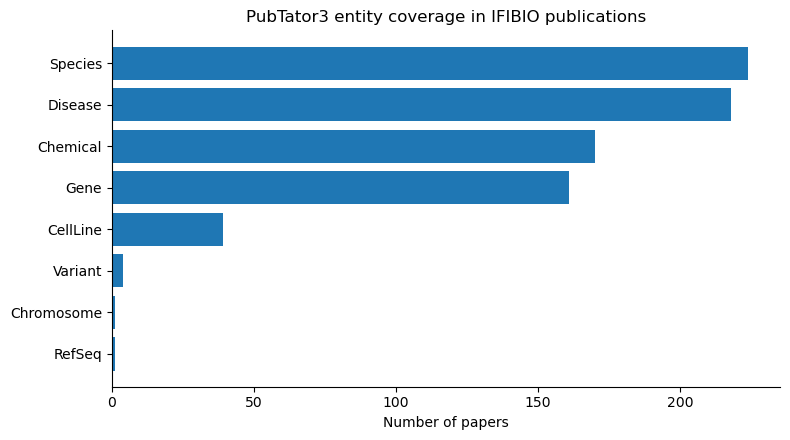

In [ ]:
# ============================================================
# ANÁLISIS INICIAL DE RESULTADOS PUBTATOR3
# Cobertura, entidades, normalización y posibles problemas
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. Resumen general
# ------------------------------------------------------------

n_papers_total = df["PMID"].dropna().astype(str).nunique()
n_papers_pubtator = pubtator_entities["PMID"].astype(str).nunique()

print("RESUMEN GENERAL")
print("-" * 60)

print(f"Papers dataset original:       {n_papers_total}")
print(f"Papers con anotaciones:        {n_papers_pubtator}")
print(f"Cobertura:                     " f"{100*n_papers_pubtator/n_papers_total:.1f}%")
print(f"Anotaciones totales:           {len(pubtator_entities):,}")


# ------------------------------------------------------------
# 2. Tipos de entidades
# ------------------------------------------------------------

entity_counts = (
    pubtator_entities.groupby("EntityType")
    .agg(
        Mentions=("Mention", "size"),
        Unique_entities=("NormalizedID", "nunique"),
        Papers=("PMID", "nunique"),
    )
    .sort_values("Mentions", ascending=False)
)

entity_counts["Papers_%"] = (100 * entity_counts["Papers"] / n_papers_total).round(1)

print("\nENTIDADES")
display(entity_counts)


# ------------------------------------------------------------
# 3. Entidades por paper
# ------------------------------------------------------------

entities_per_paper = (
    pubtator_entities.groupby(["PMID", "EntityType"])["NormalizedID"]
    .nunique()
    .unstack(fill_value=0)
)

print("\nENTIDADES ÚNICAS POR PAPER")
display(entities_per_paper.describe().round(2))


# ------------------------------------------------------------
# 4. Normalización
# ------------------------------------------------------------

normalization = (
    pubtator_entities.assign(Normalized=lambda x: x["NormalizedID"].notna())
    .groupby("EntityType")
    .agg(Total=("Mention", "size"), Normalized=("Normalized", "sum"))
)

normalization["Normalized_%"] = (
    100 * normalization["Normalized"] / normalization["Total"]
).round(1)

print("\nNORMALIZACIÓN")
display(normalization.sort_values("Total", ascending=False))


# ------------------------------------------------------------
# 5. Bases de datos utilizadas
# ------------------------------------------------------------

database_counts = (
    pubtator_entities["Database"]
    .fillna("Unknown")
    .value_counts()
    .to_frame("Annotations")
)

print("\nBASES DE DATOS")
display(database_counts)


# ------------------------------------------------------------
# 6. Entidades más frecuentes
# Usamos NormalizedID para no contar sinónimos como entidades distintas
# ------------------------------------------------------------

top_entities = (
    pubtator_entities.dropna(subset=["NormalizedID"])
    .groupby(["EntityType", "NormalizedID", "NormalizedName"], dropna=False)
    .agg(Mentions=("Mention", "size"), Papers=("PMID", "nunique"))
    .reset_index()
)

top_entities = top_entities.sort_values(
    ["EntityType", "Papers", "Mentions"], ascending=[True, False, False]
)

print("\nTOP 10 POR TIPO")

for entity_type in top_entities["EntityType"].unique():

    print(f"\n--- {entity_type} ---")

    display(
        top_entities[top_entities["EntityType"] == entity_type]
        .head(10)
        .reset_index(drop=True)
    )


# ------------------------------------------------------------
# 7. Diferencias title vs abstract
# ------------------------------------------------------------

section_counts = pd.crosstab(
    pubtator_entities["EntityType"], pubtator_entities["Section"]
)

print("\nTITLE vs ABSTRACT")
display(section_counts)


# ------------------------------------------------------------
# 8. Papers con mayor riqueza de entidades
# ------------------------------------------------------------

paper_richness = (
    pubtator_entities.dropna(subset=["NormalizedID"])
    .groupby("PMID")
    .agg(
        N_annotations=("Mention", "size"),
        N_entities=("NormalizedID", "nunique"),
        N_entity_types=("EntityType", "nunique"),
    )
    .reset_index()
)

# Añadir título
title_map = (
    df.assign(PMID=df["PMID"].astype(str).str.replace(".0", "", regex=False))
    .drop_duplicates("PMID")
    .set_index("PMID")["Title"]
)

paper_richness["Title"] = paper_richness["PMID"].map(title_map)

paper_richness = paper_richness.sort_values("N_entities", ascending=False)

print("\nPAPERS CON MAYOR NÚMERO DE ENTIDADES")
display(
    paper_richness[
        ["PMID", "Title", "N_annotations", "N_entities", "N_entity_types"]
    ].head(15)
)


# ------------------------------------------------------------
# 9. Posibles falsos positivos
#
# Una misma mención textual normalizada hacia varias entidades
# diferentes puede indicar ambigüedad.
# ------------------------------------------------------------

mention_ambiguity = (
    pubtator_entities.dropna(subset=["NormalizedID"])
    .assign(Mention_clean=lambda x: x["Mention"].astype(str).str.lower().str.strip())
    .groupby(["EntityType", "Mention_clean"])
    .agg(
        N_IDs=("NormalizedID", "nunique"),
        N_names=("NormalizedName", "nunique"),
        Papers=("PMID", "nunique"),
    )
    .reset_index()
)

mention_ambiguity = mention_ambiguity[mention_ambiguity["N_IDs"] > 1].sort_values(
    ["Papers", "N_IDs"], ascending=False
)

print("\nMENCIONES POTENCIALMENTE AMBIGUAS")
display(mention_ambiguity.head(30))


# ------------------------------------------------------------
# 10. Visualización
# ------------------------------------------------------------

plot_df = entity_counts.reset_index().sort_values("Papers", ascending=True)

fig, ax = plt.subplots(figsize=(8, 4.5))

ax.barh(plot_df["EntityType"], plot_df["Papers"])

ax.set_xlabel("Number of papers")
ax.set_ylabel("")
ax.set_title("PubTator3 entity coverage in IFIBIO publications")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()


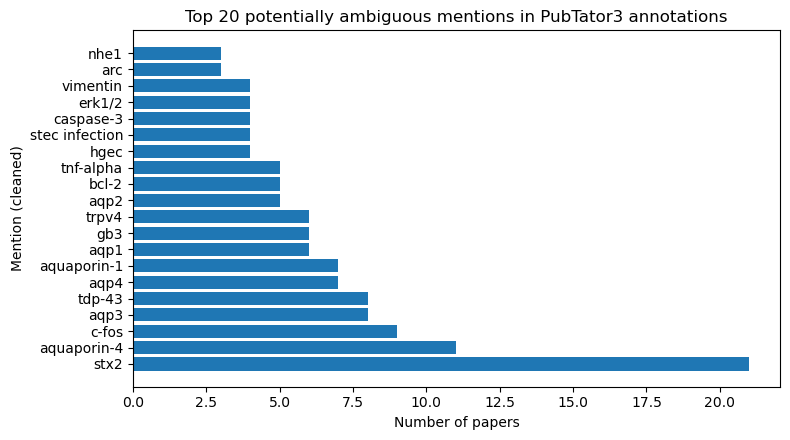

In [ ]:
# plot barra menciones ambiguas y certeras
plt.figure(figsize=(8, 4.5))
plt.barh(
    mention_ambiguity["Mention_clean"].head(20), mention_ambiguity["Papers"].head(20)
)
plt.xlabel("Number of papers")
plt.ylabel("Mention (cleaned)")
plt.title("Top 20 potentially ambiguous mentions in PubTator3 annotations")
plt.tight_layout()
plt.show()


ANÁLISIS DE GENES
------------------------------------------------------------
Anotaciones de genes: 1278
Papers con genes: 161
Gene IDs únicos: 239
Nombres normalizados únicos: 233

GENES MÁS FRECUENTES
     NormalizedID NormalizedName  Papers  Mentions  \
29           2054           STX2      15        82   
4             361           AQP4      11        67   
1             358           AQP1      10        28   
3             360           AQP3       7        52   
120         14281            Fos       7        11   
117         13489           Drd2       6        37   
5             366           AQP9       6        32   
224        230908         Tardbp       6        25   
79           6804          STX1A       6        18   
13            857           CAV1       6        13   
196         59341          TRPV4       5        38   
154         23435         TARDBP       5        23   
116         13488           Drd1       5         5   
232        519148           STX2       4

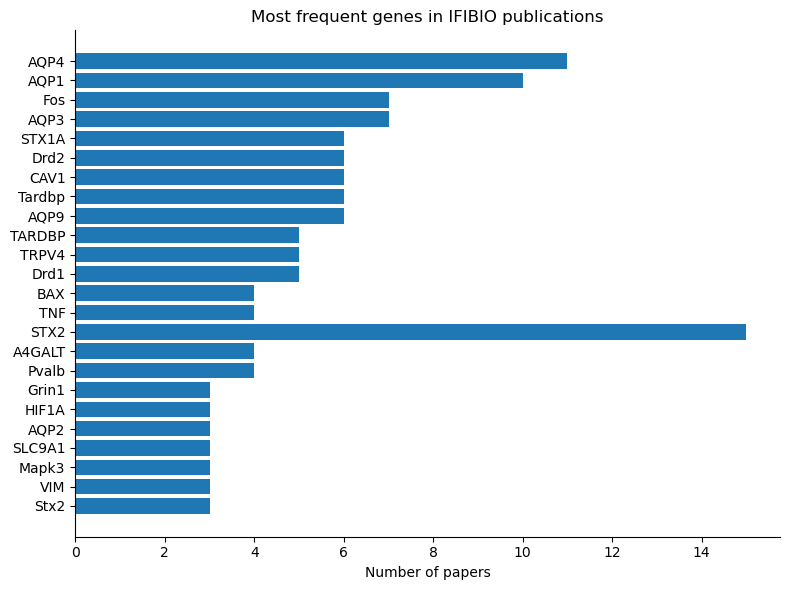

In [ ]:
# ============================================================
# ANÁLISIS DE GENES DETECTADOS POR PUBTATOR3
# ============================================================

genes = pubtator_entities[pubtator_entities["EntityType"] == "Gene"].copy()

print("ANÁLISIS DE GENES")
print("-" * 60)

print("Anotaciones de genes:", len(genes))
print("Papers con genes:", genes["PMID"].nunique())
print("Gene IDs únicos:", genes["NormalizedID"].nunique())
print("Nombres normalizados únicos:", genes["NormalizedName"].nunique())


# ------------------------------------------------------------
# Frecuencia de genes
# ------------------------------------------------------------

gene_frequency = (
    genes.dropna(subset=["NormalizedID"])
    .groupby(["NormalizedID", "NormalizedName"], dropna=False)
    .agg(
        Papers=("PMID", "nunique"),
        Mentions=("Mention", "size"),
        Mentions_text=("Mention", lambda x: ", ".join(sorted(set(x)))),
    )
    .reset_index()
    .sort_values(["Papers", "Mentions"], ascending=False)
)

print("\nGENES MÁS FRECUENTES")
print(gene_frequency.head(30))


# ------------------------------------------------------------
# Variantes textuales por gen
# ------------------------------------------------------------

gene_aliases = (
    genes.dropna(subset=["NormalizedID"])
    .groupby(["NormalizedID", "NormalizedName"])
    .agg(
        Aliases=("Mention", lambda x: sorted(set(x))),
        N_aliases=("Mention", "nunique"),
        Papers=("PMID", "nunique"),
    )
    .reset_index()
    .sort_values(["Papers", "N_aliases"], ascending=False)
)

print("\nVARIANTES TEXTUALES / ALIASES")
print(gene_aliases.head(30))


# ------------------------------------------------------------
# Una misma mención -> múltiples Gene IDs
# ------------------------------------------------------------

gene_mentions = genes.dropna(subset=["NormalizedID"]).assign(
    Mention_clean=lambda x: x["Mention"].astype(str).str.lower().str.strip()
)

gene_ambiguity = (
    gene_mentions.groupby("Mention_clean")
    .agg(
        N_gene_ids=("NormalizedID", "nunique"),
        Gene_IDs=("NormalizedID", lambda x: sorted(set(map(str, x)))),
        Gene_names=("NormalizedName", lambda x: sorted(set(map(str, x)))),
        Papers=("PMID", "nunique"),
    )
    .reset_index()
)

gene_ambiguity = gene_ambiguity[gene_ambiguity["N_gene_ids"] > 1].sort_values(
    ["Papers", "N_gene_ids"], ascending=False
)

print("\nMENCIONES DE GENES AMBIGUAS")
print(gene_ambiguity.head(30))


# ------------------------------------------------------------
# Genes por paper
# ------------------------------------------------------------

genes_per_paper = (
    genes.dropna(subset=["NormalizedID"]).groupby("PMID")["NormalizedID"].nunique()
)

print("\nGENES ÚNICOS POR PAPER")
print(genes_per_paper.describe().to_frame("N_genes"))


# ------------------------------------------------------------
# Top genes - gráfico
# ------------------------------------------------------------

plot_genes = gene_frequency.head(25).sort_values("Papers", ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))

ax.barh(plot_genes["NormalizedName"], plot_genes["Papers"])

ax.set_xlabel("Number of papers")
ax.set_ylabel("")
ax.set_title("Most frequent genes in IFIBIO publications")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()


In [ ]:
# ============================================================
# RELACIÓN GENE ↔ SPECIES EN CADA PAPER
# ============================================================

genes = (
    pubtator_entities[pubtator_entities["EntityType"] == "Gene"]
    .dropna(subset=["NormalizedID"])
    .copy()
)

species = (
    pubtator_entities[pubtator_entities["EntityType"] == "Species"]
    .dropna(subset=["NormalizedID"])
    .copy()
)

# ------------------------------------------------------------
# Especies únicas por paper
# ------------------------------------------------------------

paper_species = (
    species.groupby("PMID")
    .agg(
        Species_IDs=("NormalizedID", lambda x: sorted(set(map(str, x)))),
        Species_mentions=("Mention", lambda x: sorted(set(map(str, x)))),
        N_species=("NormalizedID", "nunique"),
    )
    .reset_index()
)

# ------------------------------------------------------------
# Genes únicos por paper
# ------------------------------------------------------------

paper_genes = genes[["PMID", "NormalizedID", "NormalizedName"]].drop_duplicates()

# ------------------------------------------------------------
# Cruzar genes con especies del mismo paper
# ------------------------------------------------------------

gene_species = paper_genes.merge(paper_species, on="PMID", how="left")

display(gene_species.head(30))


# ------------------------------------------------------------
# Gene ID -> especies de los papers donde aparece
# ------------------------------------------------------------

gene_species_summary = (
    gene_species.groupby(["NormalizedID", "NormalizedName"], dropna=False)
    .agg(
        Papers=("PMID", "nunique"),
        Species_IDs=(
            "Species_IDs",
            lambda x: sorted({item for values in x.dropna() for item in values}),
        ),
        Species_mentions=(
            "Species_mentions",
            lambda x: sorted({item for values in x.dropna() for item in values}),
        ),
    )
    .reset_index()
    .sort_values("Papers", ascending=False)
)

print("GENES Y ESPECIES ASOCIADAS")
display(gene_species_summary.head(40))


# ------------------------------------------------------------
# Analizar específicamente genes con nombres repetidos
# ------------------------------------------------------------

name_ids = (
    genes.groupby("NormalizedName").agg(N_IDs=("NormalizedID", "nunique")).reset_index()
)

repeated_names = set(name_ids.loc[name_ids["N_IDs"] > 1, "NormalizedName"])

print("\nGENES CON MÁS DE UN NCBI GENE ID")

display(
    gene_species_summary[gene_species_summary["NormalizedName"].isin(repeated_names)]
)


,PMID,NormalizedID,NormalizedName,Species_IDs,Species_mentions,N_species
0,39855537,19293,Pvalb,[10090],[mouse],1.0
1,39947439,6531,SLC6A3,[10090],[mice],1.0
2,39947439,7054,TH,[10090],[mice],1.0
3,39947439,6571,SLC18A2,[10090],[mice],1.0
4,39955250,366,AQP9,NaN,NaN,NaN
5,40527250,358,AQP1,[9606],[human],1.0
6,40527250,361,AQP4,[9606],[human],1.0
7,40527250,857,CAV1,[9606],[human],1.0
8,40553107,13492,Drd5,[10090],[mice],1.0
9,40553107,13489,Drd2,[10090],[mice],1.0


GENES Y ESPECIES ASOCIADAS


,NormalizedID,NormalizedName,Papers,Species_IDs,Species_mentions
29,2054,STX2,15,"[10090, 10116, 1038927, 562, 83334, 9606]","[E. coli, E. coli O157:H7, Escherichia coli, E..."
4,361,AQP4,11,"[10090, 562, 9606]","[Escherichia coli, Human, Patients, human, mic..."
1,358,AQP1,10,"[562, 9606]","[Escherichia coli, Human, Patients, human, pat..."
3,360,AQP3,7,"[10116, 9606]","[Human, human, rats, women]"
120,14281,Fos,7,"[10090, 9606]","[Mice, Mouse, mice, mouse, patients]"
13,857,CAV1,6,[9606],"[Human, human]"
5,366,AQP9,6,[9606],[human]
117,13489,Drd2,6,[10090],"[mice, mouse]"
224,230908,Tardbp,6,"[10090, 9606]","[Mice, human, mice, mouse, patients]"
79,6804,STX1A,6,"[10090, 10116, 1884818, 562, 83334, 9606]","[E. coli, Escherichia coli, Escherichia coli (..."



GENES CON MÁS DE UN NCBI GENE ID


,NormalizedID,NormalizedName,Papers,Species_IDs,Species_mentions
29,2054,STX2,15,"[10090, 10116, 1038927, 562, 83334, 9606]","[E. coli, E. coli O157:H7, Escherichia coli, E..."
232,519148,STX2,4,"[10090, 10116, 234, 2491679, 562, 83334, 9606,...","[Brucella, Calves, E. coli O157:H7, E. coli O2..."
119,13852,Stx2,3,"[10090, 10730, 562, 83334, 9606, 9913]","[Bacteriophage 933W, Cattle, E. coli, E. coli ..."
166,25130,Stx2,3,"[10116, 1038927, 562, 9606]","[Escherichia coli, STEC O104:H4, children, hum..."
163,24835,Tnf,2,"[10116, 562, 9606]","[Escherichia coli (, Human, rats, women]"
168,25386,Aqp2,2,[10116],[rat]
149,21926,Tnf,2,"[10090, 562]","[E. coli, mice, murine]"
105,11838,Arc,1,[10090],"[mice, mouse]"
102,11827,Aqp2,1,[],[]
146,20544,Slc9a1,1,[],[]


In [14]:
# ============================================================
# ENRIQUECIMIENTO DE NCBI GENE IDs
# Símbolo oficial + descripción + especie
# ============================================================

import requests
import pandas as pd
import time

# ------------------------------------------------------------
# Gene IDs únicos detectados por PubTator3
# ------------------------------------------------------------

gene_ids = (
    pubtator_entities.loc[pubtator_entities["EntityType"] == "Gene", "NormalizedID"]
    .dropna()
    .astype(str)
    .str.replace(".0", "", regex=False)
    .unique()
    .tolist()
)

print("NCBI Gene IDs a consultar:", len(gene_ids))


# ------------------------------------------------------------
# NCBI E-utilities
# ------------------------------------------------------------

URL = "https://eutils.ncbi.nlm.nih.gov/entrez/eutils/esummary.fcgi"

BATCH_SIZE = 100
rows = []

for start in range(0, len(gene_ids), BATCH_SIZE):

    batch = gene_ids[start : start + BATCH_SIZE]

    params = {"db": "gene", "id": ",".join(batch), "retmode": "json"}

    r = requests.get(URL, params=params, timeout=60)

    r.raise_for_status()

    result = r.json()["result"]

    for gene_id in batch:

        info = result.get(str(gene_id))

        if not info:
            continue

        rows.append(
            {
                "GeneID": str(gene_id),
                "Symbol": info.get("name"),
                "Description": info.get("description"),
                "TaxID": str(info.get("taxid", "")),
                "Organism": (info.get("organism", {}).get("scientificname")),
                "CommonName": (info.get("organism", {}).get("commonname")),
            }
        )

    print(f"{min(start+BATCH_SIZE, len(gene_ids))}" f"/{len(gene_ids)}")

    # Cortesía con NCBI
    time.sleep(0.4)


ncbi_genes = pd.DataFrame(rows)

print("\nGenes recuperados:", len(ncbi_genes))

display(ncbi_genes.head(20))


# ------------------------------------------------------------
# Distribución por especie
# ------------------------------------------------------------

print("\nGENES POR ORGANISMO")

display(
    ncbi_genes.groupby(["TaxID", "Organism"])
    .size()
    .reset_index(name="N_genes")
    .sort_values("N_genes", ascending=False)
    .head(30)
)


# ------------------------------------------------------------
# Integrar información NCBI con PubTator
# ------------------------------------------------------------

genes_enriched = pubtator_entities[pubtator_entities["EntityType"] == "Gene"].copy()

genes_enriched["NormalizedID"] = (
    genes_enriched["NormalizedID"].astype(str).str.replace(".0", "", regex=False)
)

genes_enriched = genes_enriched.merge(
    ncbi_genes, left_on="NormalizedID", right_on="GeneID", how="left"
)


# ------------------------------------------------------------
# Tabla de genes únicos
# ------------------------------------------------------------

gene_catalog = (
    genes_enriched.groupby(
        ["GeneID", "Symbol", "Description", "TaxID", "Organism"], dropna=False
    )
    .agg(
        Papers=("PMID", "nunique"),
        Mentions=("Mention", "size"),
        Text_mentions=("Mention", lambda x: sorted(set(map(str, x)))),
    )
    .reset_index()
    .sort_values(["Papers", "Mentions"], ascending=False)
)

print("\nCATÁLOGO DE GENES")

display(gene_catalog.head(40))


# ------------------------------------------------------------
# Guardar
# ------------------------------------------------------------

ncbi_genes.to_csv("ncbi_gene_metadata.csv", index=False)

genes_enriched.to_csv("pubtator3_genes_enriched.csv", index=False)

gene_catalog.to_csv("ifibio_gene_catalog.csv", index=False)


NCBI Gene IDs a consultar: 239
100/239
200/239
239/239

Genes recuperados: 239


,GeneID,Symbol,Description,TaxID,Organism,CommonName
0,19293,Pvalb,parvalbumin,,Mus musculus,house mouse
1,6531,SLC6A3,solute carrier family 6 member 3,,Homo sapiens,human
2,7054,TH,tyrosine hydroxylase,,Homo sapiens,human
3,6571,SLC18A2,solute carrier family 18 member A2,,Homo sapiens,human
4,366,AQP9,aquaporin 9,,Homo sapiens,human
5,358,AQP1,aquaporin 1 (Colton blood group),,Homo sapiens,human
6,361,AQP4,aquaporin 4,,Homo sapiens,human
7,857,CAV1,caveolin 1,,Homo sapiens,human
8,13492,Drd5,dopamine receptor D5,,Mus musculus,house mouse
9,13489,Drd2,dopamine receptor D2,,Mus musculus,house mouse



GENES POR ORGANISMO


,TaxID,Organism,N_genes
3,,Homo sapiens,119
4,,Mus musculus,64
5,,Rattus norvegicus,31
1,,Danio rerio,15
2,,Drosophila melanogaster,8
0,,Bos taurus,2



CATÁLOGO DE GENES


,GeneID,Symbol,Description,TaxID,Organism,Papers,Mentions,Text_mentions
70,2054,STX2,syntaxin 2,,Homo sapiens,15,82,"[Stx2, Stx2a, stx2]"
132,361,AQP4,aquaporin 4,,Homo sapiens,11,67,"[AQP4, AQUAPORIN-4, Aquaporin 4, Aquaporin-4, ..."
128,358,AQP1,aquaporin 1 (Colton blood group),,Homo sapiens,10,28,"[AQP1, AQP1/4, Aquaporin 1, Aquaporin-1, aquap..."
131,360,AQP3,aquaporin 3 (Gill blood group),,Homo sapiens,7,52,"[AQP3, Aquaporin 3, aquaporin 3, aquaporin-3]"
33,14281,Fos,"Fos proto-oncogene, AP-1 transcription factor ...",,Mus musculus,7,11,"[C-FOS, c-Fos]"
28,13489,Drd2,dopamine receptor D2,,Mus musculus,6,37,"[D2 receptor, D2R, Dopamine D2 receptor, Drd2,..."
134,366,AQP9,aquaporin 9,,Homo sapiens,6,32,"[AQP9, AQUAPORIN-9, Aquaporin-9]"
84,230908,Tardbp,TAR DNA binding protein,,Mus musculus,6,25,"[TAR DNA-binding protein 43, TDP-43]"
195,6804,STX1A,syntaxin 1A,,Homo sapiens,6,18,"[Stx1, stx1]"
228,857,CAV1,caveolin 1,,Homo sapiens,6,13,"[Cav-1, Caveolin-1, caveolin-1]"


In [ ]:
# ============================================================
# NORMALIZACIÓN CONCEPTUAL DE GENES ENTRE ESPECIES
# Conservamos GeneID y especie originales
# ============================================================

import pandas as pd

# ------------------------------------------------------------
# 1. Crear concepto de gen independiente de capitalización
# ------------------------------------------------------------

genes_enriched["GeneConcept"] = (
    genes_enriched["Symbol"].astype("string").str.strip().str.upper()
)

# Evitar convertir valores faltantes en texto
genes_enriched.loc[genes_enriched["Symbol"].isna(), "GeneConcept"] = pd.NA


# ------------------------------------------------------------
# 2. Catálogo conceptual
# ------------------------------------------------------------

gene_concepts = (
    genes_enriched.dropna(subset=["GeneConcept"])
    .groupby("GeneConcept")
    .agg(
        Papers=("PMID", "nunique"),
        Mentions=("Mention", "size"),
        N_GeneIDs=("GeneID", "nunique"),
        GeneIDs=("GeneID", lambda x: sorted(set(map(str, x)))),
        Symbols=("Symbol", lambda x: sorted(set(map(str, x)))),
        N_species=("TaxID", "nunique"),
        TaxIDs=("TaxID", lambda x: sorted(set(map(str, x)))),
        Organisms=("Organism", lambda x: sorted(set(x.dropna().astype(str)))),
        Text_mentions=("Mention", lambda x: sorted(set(x.dropna().astype(str)))),
    )
    .reset_index()
    .sort_values(["Papers", "Mentions"], ascending=False)
)

print("CONCEPTOS DE GEN:", len(gene_concepts))

display(gene_concepts.head(40))


# ------------------------------------------------------------
# 3. Casos donde agrupamos múltiples Gene IDs
# ------------------------------------------------------------

multi_id = gene_concepts[gene_concepts["N_GeneIDs"] > 1].sort_values(
    ["Papers", "N_GeneIDs"], ascending=False
)

print("\nCONCEPTOS CON MÚLTIPLES NCBI GENE IDs:", len(multi_id))

display(
    multi_id[
        [
            "GeneConcept",
            "Papers",
            "N_GeneIDs",
            "GeneIDs",
            "Symbols",
            "N_species",
            "Organisms",
        ]
    ].head(50)
)


# ------------------------------------------------------------
# 4. Casos sospechosos:
# mismo concepto pero múltiples IDs dentro de la MISMA especie
#
# Esto no sería explicable simplemente por ortología.
# ------------------------------------------------------------

same_species_conflicts = (
    genes_enriched.dropna(subset=["GeneConcept", "GeneID", "TaxID"])
    .groupby(["GeneConcept", "TaxID", "Organism"], dropna=False)
    .agg(
        N_GeneIDs=("GeneID", "nunique"),
        GeneIDs=("GeneID", lambda x: sorted(set(map(str, x)))),
        Symbols=("Symbol", lambda x: sorted(set(map(str, x)))),
        Papers=("PMID", "nunique"),
    )
    .reset_index()
)

same_species_conflicts = same_species_conflicts[
    same_species_conflicts["N_GeneIDs"] > 1
].sort_values(["Papers", "N_GeneIDs"], ascending=False)

print("\nPOSIBLES CONFLICTOS DENTRO DE LA MISMA ESPECIE:", len(same_species_conflicts))

display(same_species_conflicts.head(50))


# ------------------------------------------------------------
# 5. Ranking conceptual
# ------------------------------------------------------------

gene_concept_ranking = gene_concepts[
    ["GeneConcept", "Papers", "Mentions", "N_GeneIDs", "N_species", "Organisms"]
].sort_values(["Papers", "Mentions"], ascending=False)

print("\nGENES MÁS ESTUDIADOS - NIVEL CONCEPTUAL")

display(gene_concept_ranking.head(30))


# ------------------------------------------------------------
# 6. Guardar
# ------------------------------------------------------------

genes_enriched.to_csv("pubtator3_genes_normalized.csv", index=False)

gene_concepts.to_csv("ifibio_gene_concepts.csv", index=False)

same_species_conflicts.to_csv("ifibio_gene_normalization_conflicts.csv", index=False)


CONCEPTOS DE GEN: 207


,GeneConcept,Papers,Mentions,N_GeneIDs,GeneIDs,Symbols,N_species,TaxIDs,Organisms,Text_mentions
185,STX2,23,124,4,"[13852, 2054, 25130, 519148]","[STX2, Stx2]",1,[],"[Bos taurus, Homo sapiens, Mus musculus, Rattu...","[Stx2, Stx2a, stx2]"
9,AQP4,12,71,2,"[11829, 361]","[AQP4, Aqp4]",1,[],"[Homo sapiens, Mus musculus]","[AQP4, AQUAPORIN-4, Aquaporin 4, Aquaporin-4, ..."
6,AQP1,12,39,2,"[25240, 358]","[AQP1, Aqp1]",1,[],"[Homo sapiens, Rattus norvegicus]","[AQP1, AQP1/4, Aquaporin 1, Aquaporin-1, aquap..."
188,TARDBP,9,48,2,"[230908, 23435]","[TARDBP, Tardbp]",1,[],"[Homo sapiens, Mus musculus]","[TAR DNA-binding protein 43, TAR-DNA-binding p..."
73,FOS,9,16,2,"[14281, 2353]","[FOS, Fos]",1,[],"[Homo sapiens, Mus musculus]","[C-FOS, c-Fos, c-fos]"
8,AQP3,8,57,2,"[11828, 360]","[AQP3, Aqp3]",1,[],"[Homo sapiens, Mus musculus]","[AQP3, Aquaporin 3, aquaporin 3, aquaporin-3]"
195,TNF,7,23,3,"[21926, 24835, 7124]","[TNF, Tnf]",1,[],"[Homo sapiens, Mus musculus, Rattus norvegicus]","[TNF-alpha, TNFalpha, Tumor Necrosis Factor-Al..."
200,TRPV4,6,48,2,"[59341, 66026]","[TRPV4, Trpv4]",1,[],"[Homo sapiens, Rattus norvegicus]","[TRPV4, Transient Receptor Potential Vanilloid..."
60,DRD2,6,37,1,[13489],[Drd2],1,[],[Mus musculus],"[D2 receptor, D2R, Dopamine D2 receptor, Drd2,..."
10,AQP9,6,32,1,[366],[AQP9],1,[],[Homo sapiens],"[AQP9, AQUAPORIN-9, Aquaporin-9]"



CONCEPTOS CON MÚLTIPLES NCBI GENE IDs: 26


,GeneConcept,Papers,N_GeneIDs,GeneIDs,Symbols,N_species,Organisms
185,STX2,23,4,"[13852, 2054, 25130, 519148]","[STX2, Stx2]",1,"[Bos taurus, Homo sapiens, Mus musculus, Rattu..."
9,AQP4,12,2,"[11829, 361]","[AQP4, Aqp4]",1,"[Homo sapiens, Mus musculus]"
6,AQP1,12,2,"[25240, 358]","[AQP1, Aqp1]",1,"[Homo sapiens, Rattus norvegicus]"
188,TARDBP,9,2,"[230908, 23435]","[TARDBP, Tardbp]",1,"[Homo sapiens, Mus musculus]"
73,FOS,9,2,"[14281, 2353]","[FOS, Fos]",1,"[Homo sapiens, Mus musculus]"
8,AQP3,8,2,"[11828, 360]","[AQP3, Aqp3]",1,"[Homo sapiens, Mus musculus]"
195,TNF,7,3,"[21926, 24835, 7124]","[TNF, Tnf]",1,"[Homo sapiens, Mus musculus, Rattus norvegicus]"
200,TRPV4,6,2,"[59341, 66026]","[TRPV4, Trpv4]",1,"[Homo sapiens, Rattus norvegicus]"
0,A4GALT,6,2,"[53947, 63888]","[A4GALT, A4galt]",1,"[Homo sapiens, Rattus norvegicus]"
59,DRD1,6,2,"[13488, 1812]","[DRD1, Drd1]",1,"[Homo sapiens, Mus musculus]"



POSIBLES CONFLICTOS DENTRO DE LA MISMA ESPECIE: 0


,GeneConcept,TaxID,Organism,N_GeneIDs,GeneIDs,Symbols,Papers



GENES MÁS ESTUDIADOS - NIVEL CONCEPTUAL


,GeneConcept,Papers,Mentions,N_GeneIDs,N_species,Organisms
185,STX2,23,124,4,1,"[Bos taurus, Homo sapiens, Mus musculus, Rattu..."
9,AQP4,12,71,2,1,"[Homo sapiens, Mus musculus]"
6,AQP1,12,39,2,1,"[Homo sapiens, Rattus norvegicus]"
188,TARDBP,9,48,2,1,"[Homo sapiens, Mus musculus]"
73,FOS,9,16,2,1,"[Homo sapiens, Mus musculus]"
8,AQP3,8,57,2,1,"[Homo sapiens, Mus musculus]"
195,TNF,7,23,3,1,"[Homo sapiens, Mus musculus, Rattus norvegicus]"
200,TRPV4,6,48,2,1,"[Homo sapiens, Rattus norvegicus]"
60,DRD2,6,37,1,1,[Mus musculus]
10,AQP9,6,32,1,1,[Homo sapiens]


In [17]:
# ============================================================
# ENRIQUECIMIENTO DE GENES CON MyGene.info v3
# ============================================================

import requests
import pandas as pd
import time

BASE_URL = "https://mygene.info/v3/gene"

gene_ids = genes_enriched["GeneID"].dropna().astype(str).unique().tolist()

print("Genes a consultar:", len(gene_ids))

# Campos útiles para nuestro análisis
FIELDS = ",".join(
    [
        "symbol",
        "name",
        "taxid",
        "entrezgene",
        "ensembl.gene",
        "uniprot.Swiss-Prot",
        "uniprot.TrEMBL",
        "refseq.rna",
        "refseq.protein",
        "refseq.translation",
        "pathway",
        "pharmgkb",
    ]
)

rows = []

for i, gene_id in enumerate(gene_ids, start=1):

    try:

        r = requests.get(f"{BASE_URL}/{gene_id}", params={"fields": FIELDS}, timeout=30)

        if r.status_code == 404:
            continue

        r.raise_for_status()

        data = r.json()

        rows.append(
            {
                "GeneID": gene_id,
                "symbol": data.get("symbol"),
                "name": data.get("name"),
                "taxid": data.get("taxid"),
                "entrezgene": data.get("entrezgene"),
                "ensembl": data.get("ensembl"),
                "uniprot": data.get("uniprot"),
                "refseq": data.get("refseq"),
                "pathway": data.get("pathway"),
                "pharmgkb": data.get("pharmgkb"),
            }
        )

    except Exception as e:

        print(f"Error GeneID {gene_id}:", e)

    if i % 25 == 0:
        print(f"{i}/{len(gene_ids)}")

    time.sleep(0.1)


mygene_df = pd.DataFrame(rows)

print("\nGenes recuperados:", len(mygene_df))

display(mygene_df.head(20))


Genes a consultar: 239
25/239
50/239
75/239
100/239
125/239
150/239
175/239
200/239
225/239

Genes recuperados: 239


,GeneID,symbol,name,taxid,entrezgene,ensembl,uniprot,refseq,pathway,pharmgkb
0,19293,Pvalb,parvalbumin,10090,19293,"[{'gene': 'ENSMUSG00000005716'}, {'gene': 'ENS...","{'Swiss-Prot': 'P32848', 'TrEMBL': 'Q545M7'}","{'protein': ['NP_001317615.1', 'NP_038673.2'],...",None,NaN
1,6531,SLC6A3,solute carrier family 6 member 3,9606,6531,"[{'gene': 'ENSG00000276996'}, {'gene': 'ENSG00...","{'Swiss-Prot': 'Q01959', 'TrEMBL': ['A0AAQ5BGN...","{'protein': 'NP_001035.1', 'rna': 'NM_001044.5...","{'kegg': [{'id': 'hsa04721', 'name': 'Synaptic...",PA311
2,7054,TH,tyrosine hydroxylase,9606,7054,{'gene': 'ENSG00000180176'},"{'Swiss-Prot': 'P07101', 'TrEMBL': ['A0ACI8U66...","{'protein': ['NP_000351.2', 'NP_001427464.1', ...","{'humancyc': {'id': 'PWY66-301', 'name': 'cate...",PA351
3,6571,SLC18A2,solute carrier family 18 member A2,9606,6571,{'gene': 'ENSG00000165646'},"{'Swiss-Prot': 'Q05940', 'TrEMBL': ['A0ACI8T2K...","{'protein': 'NP_003045.2', 'rna': 'NM_003054.6...","{'kegg': [{'id': 'hsa04721', 'name': 'Synaptic...",PA325
4,366,AQP9,aquaporin 9,9606,366,{'gene': 'ENSG00000103569'},"{'Swiss-Prot': 'O43315', 'TrEMBL': ['A0ACI8S4N...","{'protein': ['NP_001307564.1', 'NP_001307565.1...","{'kegg': [{'id': 'hsa04613', 'name': 'Neutroph...",PA24927
5,358,AQP1,aquaporin 1 (Colton blood group),9606,358,{'gene': 'ENSG00000240583'},"{'Swiss-Prot': 'P29972', 'TrEMBL': ['A0A494C1U...","{'protein': ['NP_001316801.1', 'NP_932766.1'],...","{'kegg': [{'id': 'hsa04924', 'name': 'Renin se...",PA24918
6,361,AQP4,aquaporin 4,9606,361,{'gene': 'ENSG00000171885'},"{'Swiss-Prot': 'P55087', 'TrEMBL': ['A0A6Q8PGV...","{'protein': ['NP_001304313.1', 'NP_001304316.1...","{'kegg': [{'id': 'hsa04962', 'name': 'Vasopres...",PA24922
7,857,CAV1,caveolin 1,9606,857,{'gene': 'ENSG00000105974'},"{'Swiss-Prot': 'Q03135', 'TrEMBL': ['Q7Z4F3', ...","{'protein': ['NP_001166366.1', 'NP_001166367.1...","{'biocarta': [{'id': 'gcrpathway', 'name': 'co...",PA26107
8,13492,Drd5,dopamine receptor D5,10090,13492,"[{'gene': 'ENSMUSG00000039358'}, {'gene': 'ENS...","{'Swiss-Prot': 'Q8BLD9', 'TrEMBL': 'B2RQS5'}","{'protein': 'NP_038531.1', 'rna': 'NM_013503.4...","{'kegg': [{'id': 'mmu04020', 'name': 'Calcium ...",NaN
9,13489,Drd2,dopamine receptor D2,10090,13489,"[{'gene': 'ENSMSIG00000013494'}, {'gene': 'ENS...",{'Swiss-Prot': 'P61168'},"{'protein': ['NP_001397122.1', 'NP_034207.2'],...","{'kegg': [{'id': 'mmu04015', 'name': 'Rap1 sig...",NaN


In [ ]:
print("\nCampos disponibles en MyGene.info:")
print(
    pd.DataFrame({"Column": mygene_df.columns, "Type": mygene_df.dtypes}).reset_index(
        drop=True
    )
)


print("Resumen de los datos:")
print(f"Total de genes: {len(mygene_df)}")
print(f"Columnas: {len(mygene_df.columns)}")

# estadisticas de contenido por columna
for col in mygene_df.columns:
    n_nonnull = mygene_df[col].notna().sum()
    print(
        f"{col:20s}: {n_nonnull:5d} non-null values ({100*n_nonnull/len(mygene_df):.1f}%)"
    )



Campos disponibles en MyGene.info:
       Column    Type
0      GeneID     str
1      symbol     str
2        name     str
3       taxid   int64
4  entrezgene     str
5     ensembl  object
6     uniprot  object
7      refseq  object
8     pathway  object
9    pharmgkb     str
Resumen de los datos:
Total de genes: 239
Columnas: 10
GeneID              :   239 non-null values (100.0%)
symbol              :   239 non-null values (100.0%)
name                :   239 non-null values (100.0%)
taxid               :   239 non-null values (100.0%)
entrezgene          :   239 non-null values (100.0%)
ensembl             :   238 non-null values (99.6%)
uniprot             :   238 non-null values (99.6%)
refseq              :   238 non-null values (99.6%)
pathway             :   209 non-null values (87.4%)
pharmgkb            :   119 non-null values (49.8%)


In [ ]:
# ============================================================
# APLANAR MyGene.info:
# Ensembl, UniProt, RefSeq y Pathways
# ============================================================

import pandas as pd


def as_list(x):
    if x is None or (isinstance(x, float) and pd.isna(x)):
        return []

    if isinstance(x, list):
        return x

    return [x]


# ------------------------------------------------------------
# 1. Identificadores principales por gen
# ------------------------------------------------------------

id_rows = []

for _, row in mygene_df.iterrows():

    gene_id = str(row["GeneID"])
    symbol = row["symbol"]
    taxid = row["taxid"]

    # -------------------------
    # Ensembl
    # -------------------------

    ensembl_values = as_list(row["ensembl"])

    ensembl_ids = []

    for item in ensembl_values:

        if isinstance(item, dict):
            gene = item.get("gene")

            if isinstance(gene, list):
                ensembl_ids.extend(gene)

            elif gene:
                ensembl_ids.append(gene)

        elif isinstance(item, str):
            ensembl_ids.append(item)

    # -------------------------
    # UniProt
    # -------------------------

    swissprot = []
    trembl = []

    if isinstance(row["uniprot"], dict):

        swissprot = as_list(row["uniprot"].get("Swiss-Prot"))

        trembl = as_list(row["uniprot"].get("TrEMBL"))

    # -------------------------
    # RefSeq
    # -------------------------

    refseq_rna = []
    refseq_protein = []

    if isinstance(row["refseq"], dict):

        refseq_rna = as_list(row["refseq"].get("rna"))

        refseq_protein = as_list(row["refseq"].get("protein"))

    id_rows.append(
        {
            "GeneID": gene_id,
            "Symbol": symbol,
            "TaxID": taxid,
            "Ensembl": sorted(set(map(str, ensembl_ids))),
            "SwissProt": sorted(set(map(str, swissprot))),
            "TrEMBL": sorted(set(map(str, trembl))),
            "RefSeq_RNA": sorted(set(map(str, refseq_rna))),
            "RefSeq_Protein": sorted(set(map(str, refseq_protein))),
        }
    )


gene_ids_mygene = pd.DataFrame(id_rows)

display(gene_ids_mygene.head(20))


# ------------------------------------------------------------
# 2. Pathways
# ------------------------------------------------------------

pathway_rows = []

for _, row in mygene_df.iterrows():

    gene_id = str(row["GeneID"])
    symbol = row["symbol"]
    taxid = row["taxid"]

    pathways = row["pathway"]

    if not isinstance(pathways, dict):
        continue

    for source, entries in pathways.items():

        entries = as_list(entries)

        for entry in entries:

            if isinstance(entry, dict):

                pathway_rows.append(
                    {
                        "GeneID": gene_id,
                        "Symbol": symbol,
                        "TaxID": taxid,
                        "PathwaySource": source,
                        "PathwayID": entry.get("id"),
                        "PathwayName": entry.get("name"),
                    }
                )

            elif isinstance(entry, str):

                pathway_rows.append(
                    {
                        "GeneID": gene_id,
                        "Symbol": symbol,
                        "TaxID": taxid,
                        "PathwaySource": source,
                        "PathwayID": None,
                        "PathwayName": entry,
                    }
                )


mygene_pathways = pd.DataFrame(pathway_rows)

print("\nPATHWAY SOURCES")
print("-" * 60)

pathway_summary = (
    mygene_pathways.groupby("PathwaySource")
    .agg(
        Genes=("GeneID", "nunique"),
        Pathways=("PathwayID", "nunique"),
        Annotations=("GeneID", "size"),
    )
    .sort_values(["Genes", "Annotations"], ascending=False)
)

display(pathway_summary)


# ------------------------------------------------------------
# 3. Pathways más representados en el corpus
# ------------------------------------------------------------

top_pathways = (
    mygene_pathways.groupby(["PathwaySource", "PathwayID", "PathwayName"], dropna=False)
    .agg(Genes=("GeneID", "nunique"))
    .reset_index()
    .sort_values(["Genes", "PathwaySource"], ascending=[False, True])
)

print("\nPATHWAYS CON MÁS GENES DEL CORPUS")

display(top_pathways.head(40))


# ------------------------------------------------------------
# 4. Cobertura de identificadores
# ------------------------------------------------------------

coverage = pd.DataFrame(
    {
        "Field": ["Ensembl", "SwissProt", "TrEMBL", "RefSeq_RNA", "RefSeq_Protein"],
        "Genes_with_value": [
            gene_ids_mygene["Ensembl"].apply(len).gt(0).sum(),
            gene_ids_mygene["SwissProt"].apply(len).gt(0).sum(),
            gene_ids_mygene["TrEMBL"].apply(len).gt(0).sum(),
            gene_ids_mygene["RefSeq_RNA"].apply(len).gt(0).sum(),
            gene_ids_mygene["RefSeq_Protein"].apply(len).gt(0).sum(),
        ],
    }
)

coverage["Coverage_%"] = (
    100 * coverage["Genes_with_value"] / len(gene_ids_mygene)
).round(1)

print("\nCOBERTURA DE IDENTIFICADORES")

display(coverage)


# ------------------------------------------------------------
# 5. Guardar
# ------------------------------------------------------------

gene_ids_mygene.to_csv("ifibio_gene_identifiers_mygene.csv", index=False)

mygene_pathways.to_csv("ifibio_gene_pathways_mygene.csv", index=False)

top_pathways.to_csv("ifibio_top_pathways_mygene.csv", index=False)


,GeneID,Symbol,TaxID,Ensembl,SwissProt,TrEMBL,RefSeq_RNA,RefSeq_Protein
0,19293,Pvalb,10090,"[ENSMSIG00000020723, ENSMUSG00000005716, ENSNV...",[P32848],[Q545M7],"[NM_001330686.1, NM_013645.4]","[NP_001317615.1, NP_038673.2]"
1,6531,SLC6A3,9606,"[ENSG00000142319, ENSG00000276996]",[Q01959],"[A0AAQ5BGN6, A0AAQ5BGQ7, A0AAQ5BGS7, A0ACI8TX5...",[NM_001044.5],[NP_001035.1]
2,7054,TH,9606,[ENSG00000180176],[P07101],"[A0ACI8U525, A0ACI8U667, E7EQI0, F8W8M5, H0Y67...","[NM_000360.4, NM_001440535.1, NM_001440536.1, ...","[NP_000351.2, NP_001427464.1, NP_001427465.1, ..."
3,6571,SLC18A2,9606,[ENSG00000165646],[Q05940],"[A0ACI8PHI4, A0ACI8Q4C0, A0ACI8QNJ1, A0ACI8T2A...",[NM_003054.6],[NP_003045.2]
4,366,AQP9,9606,[ENSG00000103569],[O43315],"[A0ACI8PPV4, A0ACI8QSK3, A0ACI8RHH2, A0ACI8S4N...","[NM_001320635.2, NM_001320636.1, NM_020980.5]","[NP_001307564.1, NP_001307565.1, NP_066190.2]"
5,358,AQP1,9606,[ENSG00000240583],[P29972],"[A0A494C115, A0A494C1U4, A0ACI8PQD6, A0ACI8RI3...","[NM_000385.3, NM_001185060.1, NM_001185061.1, ...","[NP_001316801.1, NP_932766.1]"
6,361,AQP4,9606,[ENSG00000171885],[P55087],"[A0A5F9ZHR4, A0A6Q8PGV0, A0ACI8RHF7, F1DSG4, H...","[NM_001317384.3, NM_001317387.3, NM_001364286....","[NP_001304313.1, NP_001304316.1, NP_001351215...."
7,857,CAV1,9606,[ENSG00000105974],[Q03135],"[A0A7P0YWJ6, A0ACI8TRI8, A9XTE5, C9JKI3, E9PCT...","[NM_001172895.1, NM_001172896.2, NM_001172897....","[NP_001166366.1, NP_001166367.1, NP_001166368...."
8,13492,Drd5,10090,"[ENSFALG00000009387, ENSMSIG00000025736, ENSMU...",[Q8BLD9],[B2RQS5],[NM_013503.4],[NP_038531.1]
9,13489,Drd2,10090,"[ENSMSIG00000013494, ENSMUSG00000032259, ENSNV...",[P61168],[],"[NM_001410193.1, NM_010077.3]","[NP_001397122.1, NP_034207.2]"



PATHWAY SOURCES
------------------------------------------------------------


,Genes,Pathways,Annotations
PathwaySource,,,
kegg,153,441,2309
wikipathways,97,363,1272
pid,60,163,478
reactome,45,453,575
biocarta,39,143,245
netpath,27,33,125
smpdb,23,166,341
humancyc,10,14,17
mousecyc,7,6,8



PATHWAYS CON MÁS GENES DEL CORPUS


,PathwaySource,PathwayID,PathwayName,Genes
346,kegg,hsa05200,Pathways in cancer - Homo sapiens (human),21
1696,wikipathways,WP4754,IL-18 signaling pathway,21
384,kegg,hsa05417,Lipid and atherosclerosis - Homo sapiens (human),20
203,kegg,hsa04151,PI3K-Akt signaling pathway - Homo sapiens (human),17
292,kegg,hsa04933,AGE-RAGE signaling pathway in diabetic complic...,17
338,kegg,hsa05164,Influenza A - Homo sapiens (human),17
349,kegg,hsa05205,Proteoglycans in cancer - Homo sapiens (human),17
385,kegg,hsa05418,Fluid shear stress and atherosclerosis - Homo ...,17
410,kegg,mmu04024,cAMP signaling pathway - Mus musculus (mouse),17
529,kegg,mmu05022,Pathways of neurodegeneration - multiple disea...,17



COBERTURA DE IDENTIFICADORES


,Field,Genes_with_value,Coverage_%
0,Ensembl,238,99.6
1,SwissProt,214,89.5
2,TrEMBL,197,82.4
3,RefSeq_RNA,236,98.7
4,RefSeq_Protein,238,99.6


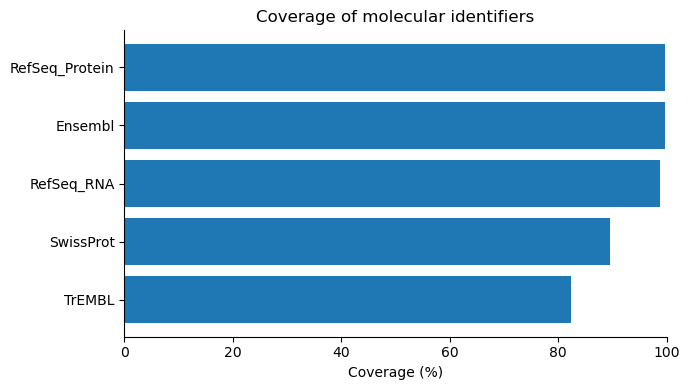

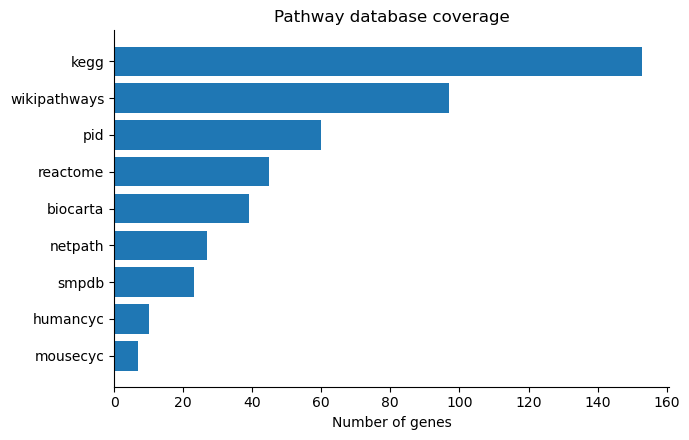

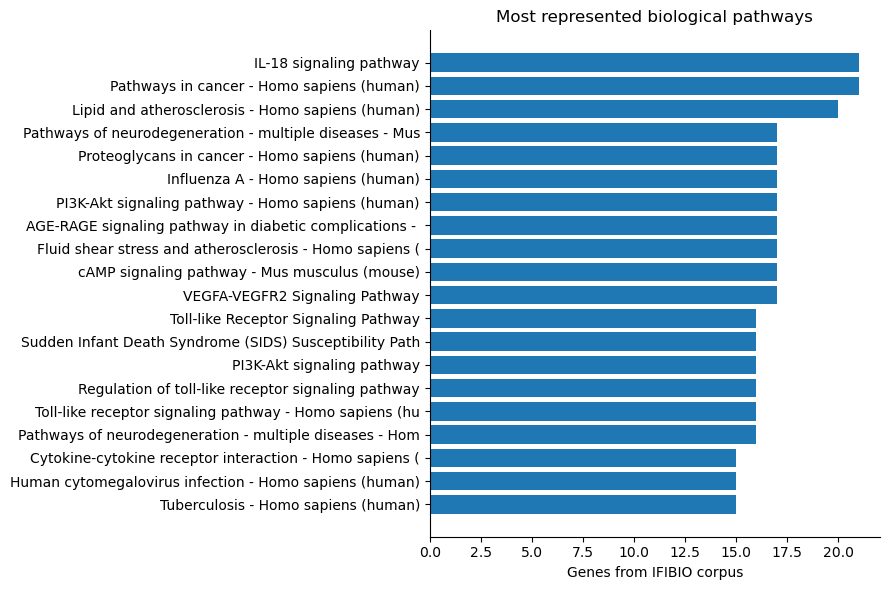

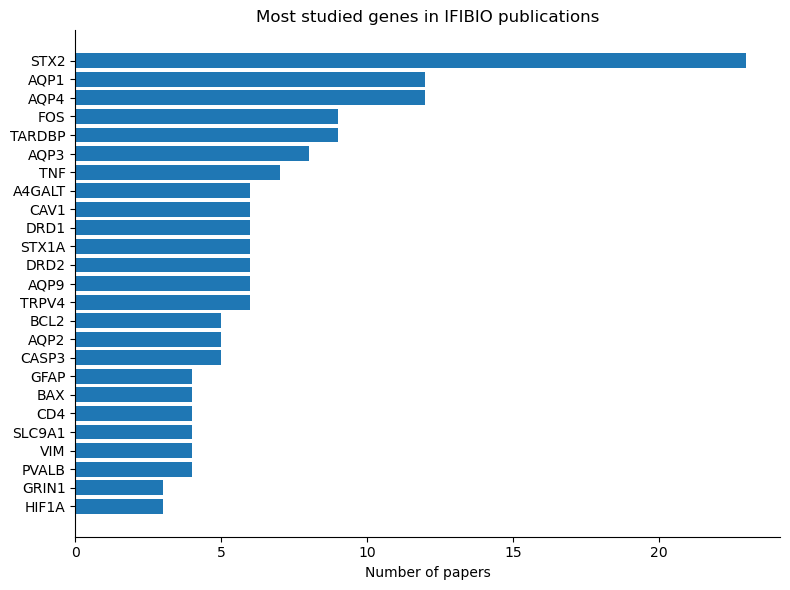

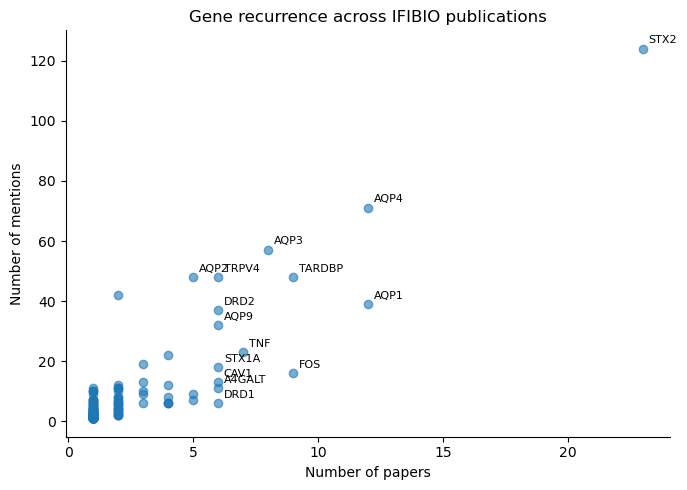

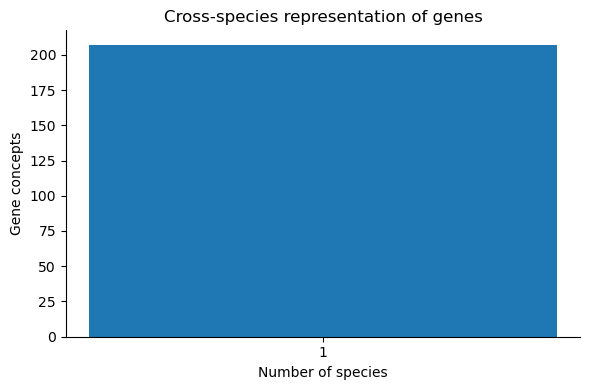

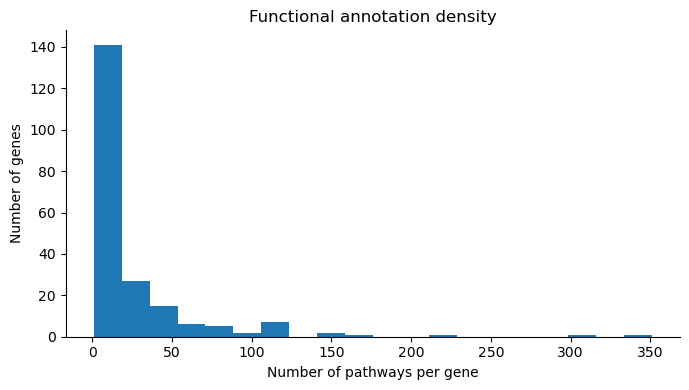

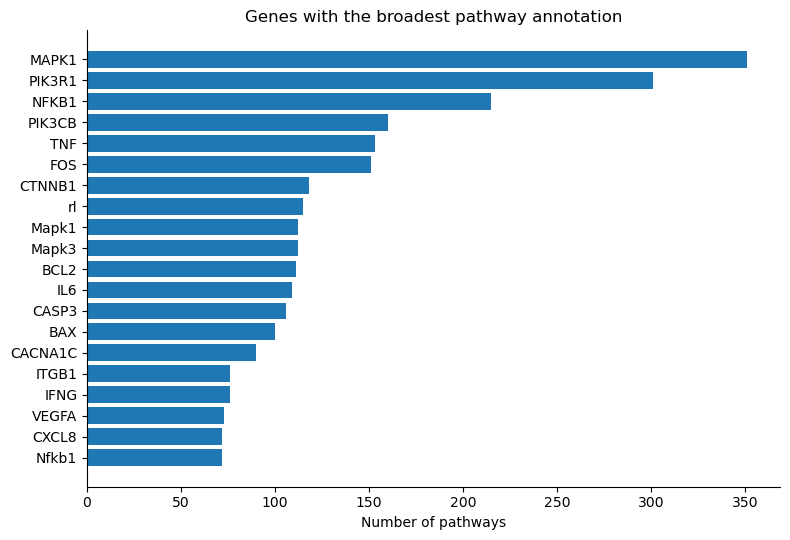

In [ ]:
# ============================================================
# PLOTS BIOLOGICAL ENRICHMENT - IFIBIO
# MyGene / PubTator3
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. Cobertura de identificadores
# ------------------------------------------------------------

plot_cov = coverage.sort_values("Coverage_%", ascending=True)

fig, ax = plt.subplots(figsize=(7, 4))

ax.barh(plot_cov["Field"], plot_cov["Coverage_%"])

ax.set_xlabel("Coverage (%)")
ax.set_ylabel("")
ax.set_title("Coverage of molecular identifiers")

ax.set_xlim(0, 100)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 2. Fuentes de pathways
# ------------------------------------------------------------

plot_sources = pathway_summary.reset_index().sort_values("Genes", ascending=True)

fig, ax = plt.subplots(figsize=(7, 4.5))

ax.barh(plot_sources["PathwaySource"], plot_sources["Genes"])

ax.set_xlabel("Number of genes")
ax.set_ylabel("")
ax.set_title("Pathway database coverage")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 3. Top pathways por número de genes
# ------------------------------------------------------------

plot_pathways = top_pathways.dropna(subset=["PathwayName"]).head(20).copy()

plot_pathways["Label"] = plot_pathways["PathwayName"].astype(str).str.slice(0, 55)

plot_pathways = plot_pathways.sort_values("Genes", ascending=True)

fig, ax = plt.subplots(figsize=(9, 6))

ax.barh(plot_pathways["Label"], plot_pathways["Genes"])

ax.set_xlabel("Genes from IFIBIO corpus")
ax.set_ylabel("")
ax.set_title("Most represented biological pathways")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 4. Top genes por número de papers
# ------------------------------------------------------------

plot_genes = (
    gene_concepts[["GeneConcept", "Papers", "Mentions"]]
    .head(25)
    .sort_values("Papers", ascending=True)
)

fig, ax = plt.subplots(figsize=(8, 6))

ax.barh(plot_genes["GeneConcept"], plot_genes["Papers"])

ax.set_xlabel("Number of papers")
ax.set_ylabel("")
ax.set_title("Most studied genes in IFIBIO publications")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 5. Papers vs mentions
# Detecta genes centrales/recurrentes
# ------------------------------------------------------------

plot_scatter = gene_concepts.copy()

fig, ax = plt.subplots(figsize=(7, 5))

ax.scatter(plot_scatter["Papers"], plot_scatter["Mentions"], alpha=0.6)

ax.set_xlabel("Number of papers")
ax.set_ylabel("Number of mentions")
ax.set_title("Gene recurrence across IFIBIO publications")

# Etiquetar genes más importantes
top_label = plot_scatter.sort_values(["Papers", "Mentions"], ascending=False).head(15)

for _, row in top_label.iterrows():

    ax.annotate(
        row["GeneConcept"],
        (row["Papers"], row["Mentions"]),
        xytext=(4, 4),
        textcoords="offset points",
        fontsize=8,
    )

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 6. Diversidad de especies por concepto de gen
# ------------------------------------------------------------

species_counts = gene_concepts["N_species"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(6, 4))

ax.bar(species_counts.index.astype(str), species_counts.values)

ax.set_xlabel("Number of species")
ax.set_ylabel("Gene concepts")
ax.set_title("Cross-species representation of genes")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 7. Número de pathways por gen
# ------------------------------------------------------------

pathways_per_gene = mygene_pathways.groupby("GeneID")["PathwayID"].nunique()

fig, ax = plt.subplots(figsize=(7, 4))

ax.hist(pathways_per_gene, bins=20)

ax.set_xlabel("Number of pathways per gene")
ax.set_ylabel("Number of genes")
ax.set_title("Functional annotation density")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 8. Top genes por número de pathways
# ------------------------------------------------------------

gene_pathway_count = (
    mygene_pathways.groupby(["GeneID", "Symbol"])["PathwayID"]
    .nunique()
    .reset_index(name="N_pathways")
    .sort_values("N_pathways", ascending=False)
)

plot_gene_pathways = gene_pathway_count.head(20).sort_values(
    "N_pathways", ascending=True
)

fig, ax = plt.subplots(figsize=(8, 5.5))

ax.barh(plot_gene_pathways["Symbol"], plot_gene_pathways["N_pathways"])

ax.set_xlabel("Number of pathways")
ax.set_ylabel("")
ax.set_title("Genes with the broadest pathway annotation")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()


Anotaciones originales: 5370
Gene concepts: 182
Asociaciones GeneConcept–Pathway: 5370
Gene concepts con pathways: 182
Pathways únicos: 1782

PATHWAYS MÁS REPRESENTADOS


,PathwaySource,PathwayID,PathwayName,N_genes,Genes
346,kegg,hsa05200,Pathways in cancer - Homo sapiens (human),21,"[BAX, BCL2, CAMK2G, CASP3, CTNNB1, CXCL8, ESR1..."
1696,wikipathways,WP4754,IL-18 signaling pathway,21,"[BAX, BCL2, CASP3, CCL2, CCL3, CCL5, CTNNB1, C..."
384,kegg,hsa05417,Lipid and atherosclerosis - Homo sapiens (human),20,"[BAX, BCL2, CAMK2G, CASP3, CCL2, CCL3, CCL5, C..."
203,kegg,hsa04151,PI3K-Akt signaling pathway - Homo sapiens (human),17,"[BCL2, CSF3, EREG, FLT1, IFNA1, IL6, ITGB1, KD..."
292,kegg,hsa04933,AGE-RAGE signaling pathway in diabetic complic...,17,"[BAX, BCL2, CASP3, CCL2, CXCL8, EGR1, IL1A, IL..."
338,kegg,hsa05164,Influenza A - Homo sapiens (human),17,"[BAX, CASP3, CCL2, CCL5, CXCL10, CXCL8, IFNA1,..."
349,kegg,hsa05205,Proteoglycans in cancer - Homo sapiens (human),17,"[CAMK2G, CASP3, CAV1, CTNNB1, ESR1, HIF1A, ITG..."
385,kegg,hsa05418,Fluid shear stress and atherosclerosis - Homo ...,17,"[BCL2, CAV1, CCL2, CTNNB1, FOS, IFNG, IL1A, KD..."
410,kegg,mmu04024,cAMP signaling pathway - Mus musculus (mouse),17,"[CAMK2D, DRD1, DRD2, DRD5, FOS, GRIN1, HTR1A, ..."
529,kegg,mmu05022,Pathways of neurodegeneration - multiple disea...,17,"[BCL2, BCL2L1, BID, CAMK2D, CASP3, CASP8, CASP..."



GENES CON MAYOR DIVERSIDAD FUNCIONAL


,GeneConcept,N_pathways,N_sources,Sources,Pathways
104,MAPK1,464,7,"[biocarta, humancyc, kegg, netpath, pid, smpdb...","[4-hydroxytamoxifen, Dexamethasone, and Retino..."
127,PIK3R1,302,7,"[biocarta, humancyc, kegg, netpath, pid, smpdb...","[3-phosphoinositide biosynthesis, AGE-RAGE sig..."
113,NFKB1,287,6,"[biocarta, kegg, netpath, pid, smpdb, wikipath...","[16p11.2 proximal deletion syndrome, AGE-RAGE ..."
171,TNF,228,7,"[biocarta, kegg, netpath, pid, reactome, smpdb...",[AGE-RAGE signaling pathway in diabetic compli...
65,FOS,195,5,"[biocarta, kegg, netpath, pid, wikipathways]","[AP-1 transcription factor network, ATF-2 tran..."
126,PIK3CB,160,5,"[humancyc, kegg, netpath, pid, wikipathways]","[3-phosphoinositide biosynthesis, AGE-RAGE sig..."
13,BCL2,151,5,"[biocarta, kegg, netpath, pid, wikipathways]","[22q11.2 copy number variation syndrome, AGE-R..."
22,CASP3,149,5,"[biocarta, kegg, netpath, pid, wikipathways]","[AGE-RAGE pathway, AGE-RAGE signaling pathway ..."
44,CTNNB1,118,5,"[biocarta, kegg, netpath, pid, wikipathways]","[1q21.1 copy number variation syndrome, AP-1 t..."
137,RL,115,1,[reactome],[Activation of the AP-1 family of transcriptio...



Matriz Gene × Pathway: (176, 1033)


PathwayName,16p11.2 proximal deletion syndrome,22q11.2 copy number variation syndrome,3-Methylthiofentanyl Action Pathway,3-phosphoinositide biosynthesis,ACE Inhibitor Pathway,AGE-RAGE pathway,AGE-RAGE signaling pathway in diabetic complications - Homo sapiens (human),AGE-RAGE signaling pathway in diabetic complications - Mus musculus (mouse),ALK1 signaling events,AMP-activated protein kinase (AMPK) signaling,AMPK signaling pathway - Homo sapiens (human),AP-1 transcription factor network,ATF-2 transcription factor network,Acebutolol Action Pathway,Acute myeloid leukemia - Homo sapiens (human)
GeneConcept,,,,,,,,,,,,,,,
A4GALT,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
ACE2,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0
ACHE,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
ADORA2A,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
AQP1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
AQP2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
AQP3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
AQP4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
AQP9,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


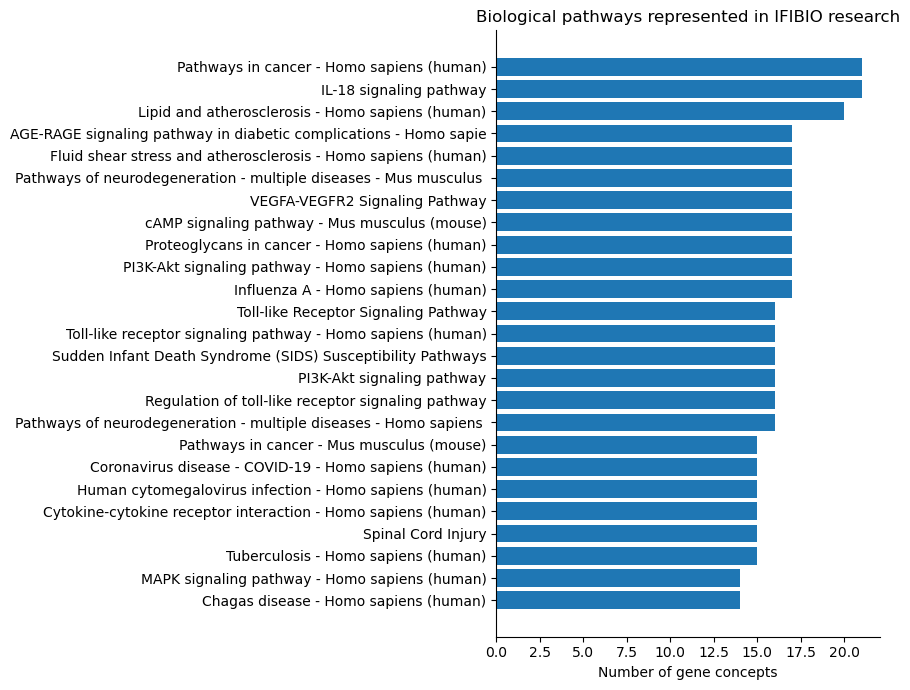

In [ ]:
# ============================================================
# GENE CONCEPT → PATHWAY
# Integración funcional independiente de especie
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. Mapa GeneID -> GeneConcept
# ------------------------------------------------------------

gene_map = (
    genes_enriched[["GeneID", "GeneConcept", "Symbol", "TaxID", "Organism"]]
    .dropna(subset=["GeneID", "GeneConcept"])
    .drop_duplicates()
)

gene_map["GeneID"] = gene_map["GeneID"].astype(str)

mygene_pathways["GeneID"] = mygene_pathways["GeneID"].astype(str)


# ------------------------------------------------------------
# 2. Integrar pathways con GeneConcept
# ------------------------------------------------------------

concept_pathways_raw = mygene_pathways.merge(gene_map, on="GeneID", how="left")

print("Anotaciones originales:", len(concept_pathways_raw))
print("Gene concepts:", concept_pathways_raw["GeneConcept"].nunique())


# ------------------------------------------------------------
# 3. Eliminar duplicados por ortología
#
# Mismo concepto + misma fuente + mismo pathway
# = una única asociación funcional
# ------------------------------------------------------------

concept_pathways = (
    concept_pathways_raw.dropna(subset=["GeneConcept", "PathwaySource", "PathwayName"])
    .drop_duplicates(
        subset=["GeneConcept", "PathwaySource", "PathwayID", "PathwayName"]
    )
    .copy()
)

print("Asociaciones GeneConcept–Pathway:", len(concept_pathways))

print("Gene concepts con pathways:", concept_pathways["GeneConcept"].nunique())

print(
    "Pathways únicos:",
    concept_pathways[["PathwaySource", "PathwayID", "PathwayName"]]
    .drop_duplicates()
    .shape[0],
)


# ------------------------------------------------------------
# 4. Ranking de pathways
# ------------------------------------------------------------

concept_pathway_ranking = (
    concept_pathways.groupby(
        ["PathwaySource", "PathwayID", "PathwayName"], dropna=False
    )
    .agg(
        N_genes=("GeneConcept", "nunique"),
        Genes=("GeneConcept", lambda x: sorted(set(x))),
    )
    .reset_index()
    .sort_values(["N_genes", "PathwaySource"], ascending=[False, True])
)

print("\nPATHWAYS MÁS REPRESENTADOS")

display(concept_pathway_ranking.head(40))


# ------------------------------------------------------------
# 5. Perfil funcional por gen
# ------------------------------------------------------------

gene_functional_profile = (
    concept_pathways.groupby("GeneConcept")
    .agg(
        N_pathways=("PathwayName", "nunique"),
        N_sources=("PathwaySource", "nunique"),
        Sources=("PathwaySource", lambda x: sorted(set(x))),
        Pathways=("PathwayName", lambda x: sorted(set(x))),
    )
    .reset_index()
    .sort_values("N_pathways", ascending=False)
)

print("\nGENES CON MAYOR DIVERSIDAD FUNCIONAL")

display(gene_functional_profile.head(30))


# ------------------------------------------------------------
# 6. Matriz GeneConcept × Pathway
#
# Sólo pathways compartidos por >= 2 genes
# para evitar una matriz excesivamente dispersa
# ------------------------------------------------------------

shared_pathways = set(
    concept_pathway_ranking.loc[concept_pathway_ranking["N_genes"] >= 2, "PathwayName"]
)

matrix_data = concept_pathways[concept_pathways["PathwayName"].isin(shared_pathways)][
    ["GeneConcept", "PathwayName"]
].drop_duplicates()

gene_pathway_matrix = pd.crosstab(
    matrix_data["GeneConcept"], matrix_data["PathwayName"]
)

gene_pathway_matrix = (gene_pathway_matrix > 0).astype(int)

print("\nMatriz Gene × Pathway:", gene_pathway_matrix.shape)

display(gene_pathway_matrix.iloc[:15, :15])


# ------------------------------------------------------------
# 7. Pathways compartidos por mayor número de genes
# ------------------------------------------------------------

plot_df = concept_pathway_ranking.dropna(subset=["PathwayName"]).head(25).copy()

plot_df["Label"] = (
    plot_df["PathwayName"]
    .astype(str)
    .str.replace("_", " ", regex=False)
    .str.slice(0, 65)
)

plot_df = plot_df.sort_values("N_genes", ascending=True)

fig, ax = plt.subplots(figsize=(9, 7))

ax.barh(plot_df["Label"], plot_df["N_genes"])

ax.set_xlabel("Number of gene concepts")
ax.set_ylabel("")
ax.set_title("Biological pathways represented in IFIBIO research")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 8. Guardar
# ------------------------------------------------------------

concept_pathways.to_csv("ifibio_geneconcept_pathways.csv", index=False)

concept_pathway_ranking.to_csv("ifibio_pathway_ranking.csv", index=False)

gene_functional_profile.to_csv("ifibio_gene_functional_profile.csv", index=False)

gene_pathway_matrix.to_csv("ifibio_gene_pathway_matrix.csv")


Gene concepts con pathways: 182
Pathways: 1782


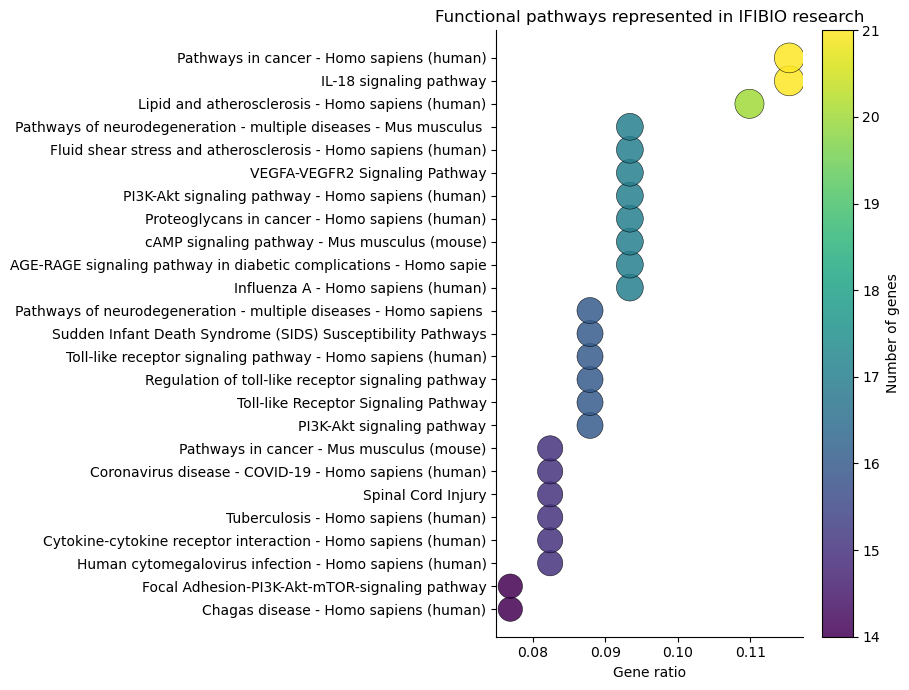

Fuentes usadas en Venn: ['kegg', 'wikipathways', 'pid']


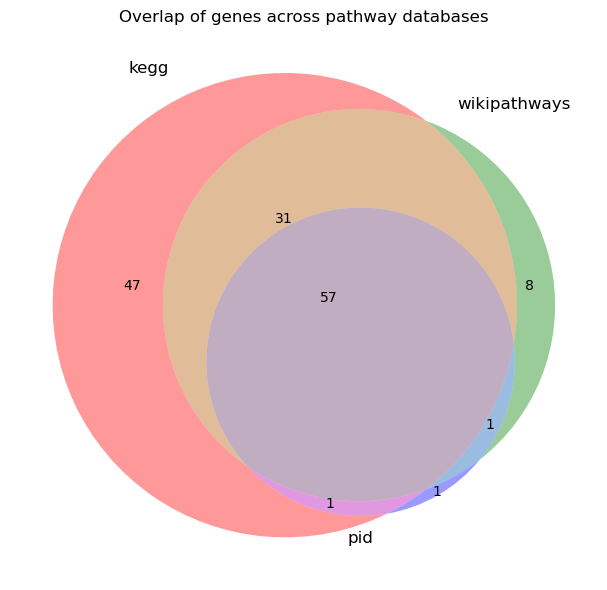

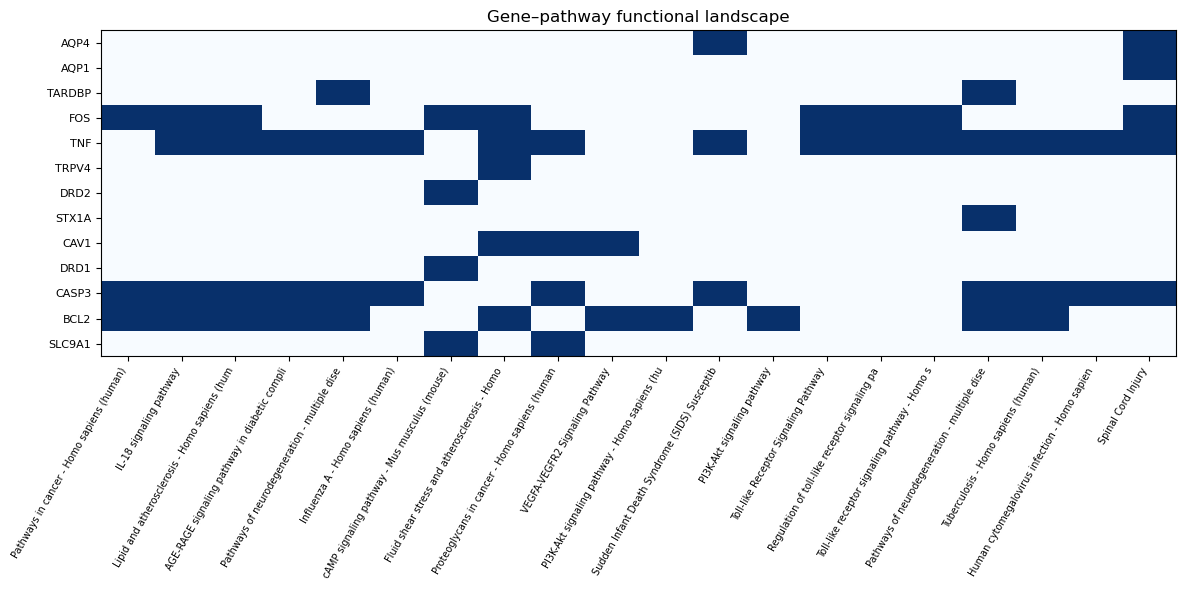

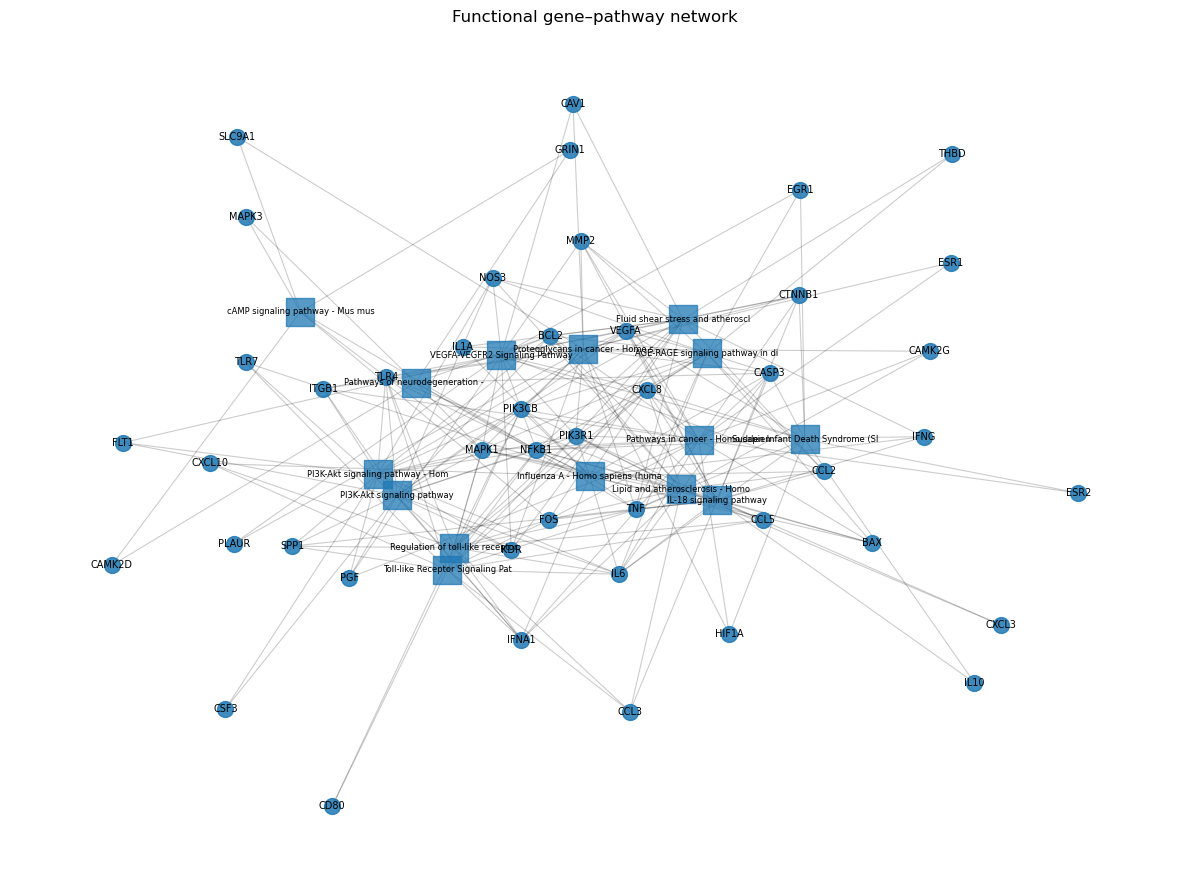

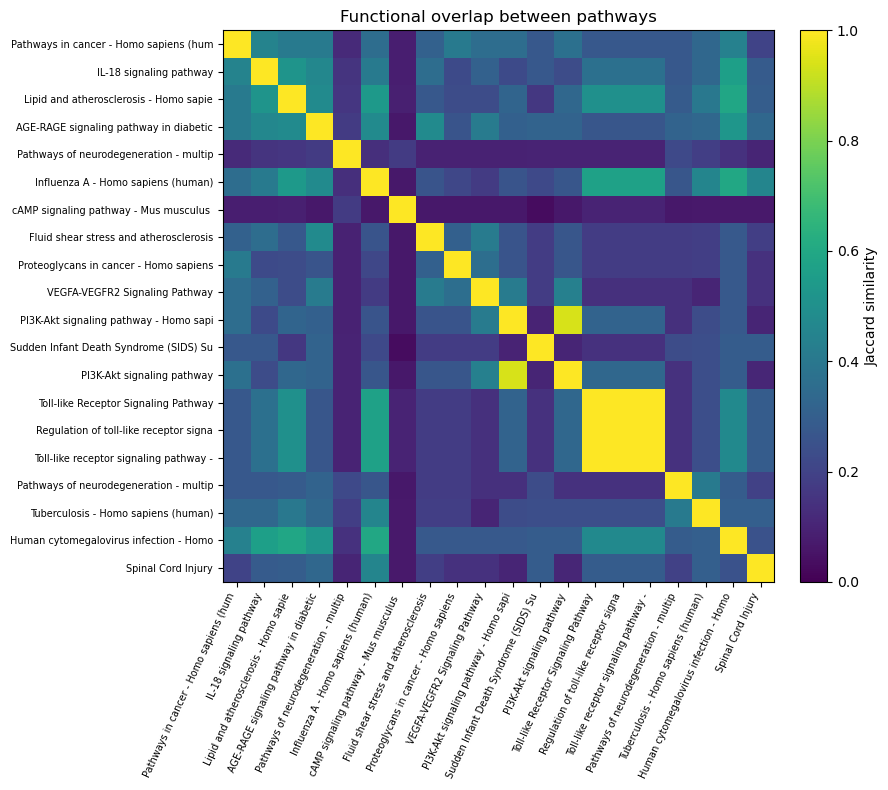

In [ ]:
# ============================================================
# BIOLOGICAL PLOTS — IFIBIO
# GeneConcept ↔ Pathway
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

# Si no está instalado:
# !pip install matplotlib-venn

from matplotlib_venn import venn3

# ============================================================
# PREPARACIÓN GENERAL
# ============================================================

cp = concept_pathways.copy()

# Número total de conceptos génicos con al menos un pathway
N_GENES = cp["GeneConcept"].nunique()

# Resumen pathway
pathway_plot = (
    cp.groupby(["PathwaySource", "PathwayID", "PathwayName"], dropna=False)
    .agg(
        N_genes=("GeneConcept", "nunique"),
        Genes=("GeneConcept", lambda x: sorted(set(x))),
    )
    .reset_index()
)

pathway_plot["GeneRatio"] = pathway_plot["N_genes"] / N_GENES

pathway_plot = pathway_plot.sort_values("N_genes", ascending=False)

print("Gene concepts con pathways:", N_GENES)
print("Pathways:", len(pathway_plot))


# ============================================================
# 1. DOTPLOT TIPO GO ENRICHMENT
# ============================================================

top = pathway_plot.head(25).copy()

top["Label"] = (
    top["PathwayName"].astype(str).str.replace("_", " ", regex=False).str.slice(0, 65)
)

top = top.sort_values("GeneRatio")

fig, ax = plt.subplots(figsize=(9, 7))

sc = ax.scatter(
    top["GeneRatio"],
    top["Label"],
    s=top["N_genes"] * 22,
    c=top["N_genes"],
    cmap="viridis",
    alpha=0.85,
    edgecolors="black",
    linewidths=0.4,
)

ax.set_xlabel("Gene ratio")
ax.set_ylabel("")
ax.set_title("Functional pathways represented in IFIBIO research")

cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("Number of genes")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()


# ============================================================
# 2. VENN — SOLAPAMIENTO ENTRE LAS 3 PRINCIPALES
#    FUENTES DE PATHWAYS
# ============================================================

source_rank = (
    cp.groupby("PathwaySource")["GeneConcept"].nunique().sort_values(ascending=False)
)

top_sources = source_rank.head(3).index.tolist()

print("Fuentes usadas en Venn:", top_sources)

sets = {}

for source in top_sources:

    sets[source] = set(cp.loc[cp["PathwaySource"] == source, "GeneConcept"])

fig, ax = plt.subplots(figsize=(7, 6))

venn3(
    [sets[top_sources[0]], sets[top_sources[1]], sets[top_sources[2]]],
    set_labels=top_sources,
    ax=ax,
)

ax.set_title("Overlap of genes across pathway databases")

plt.tight_layout()
plt.show()


# ============================================================
# 3. HEATMAP GENES × PATHWAYS
#
# Top genes y pathways compartidos
# ============================================================

top_gene_names = (
    gene_concepts.sort_values(["Papers", "Mentions"], ascending=False)
    .head(20)["GeneConcept"]
    .tolist()
)

top_pathway_names = (
    pathway_plot[pathway_plot["N_genes"] >= 2].head(20)["PathwayName"].tolist()
)

heat_data = cp[
    cp["GeneConcept"].isin(top_gene_names) & cp["PathwayName"].isin(top_pathway_names)
][["GeneConcept", "PathwayName"]].drop_duplicates()

heat_matrix = pd.crosstab(heat_data["GeneConcept"], heat_data["PathwayName"])

# asegurar orden
heat_matrix = heat_matrix.reindex(
    index=[x for x in top_gene_names if x in heat_matrix.index],
    columns=[x for x in top_pathway_names if x in heat_matrix.columns],
    fill_value=0,
)

fig, ax = plt.subplots(figsize=(12, 6))

im = ax.imshow(heat_matrix.values, aspect="auto", interpolation="nearest", cmap="Blues")

ax.set_yticks(np.arange(len(heat_matrix.index)))

ax.set_yticklabels(heat_matrix.index, fontsize=8)

ax.set_xticks(np.arange(len(heat_matrix.columns)))

ax.set_xticklabels(
    [str(x)[:45] for x in heat_matrix.columns], rotation=60, ha="right", fontsize=7
)

ax.set_xlabel("")
ax.set_ylabel("")
ax.set_title("Gene–pathway functional landscape")

plt.tight_layout()
plt.show()


# ============================================================
# 4. RED BIPARTITA
#    genes ↔ pathways
# ============================================================

# restringimos para que sea interpretable
network_pathways = (
    pathway_plot[pathway_plot["N_genes"] >= 3].head(15)["PathwayName"].tolist()
)

network_data = cp[cp["PathwayName"].isin(network_pathways)][
    ["GeneConcept", "PathwayName"]
].drop_duplicates()

# conservar genes conectados a >= 2 de esos pathways
gene_degree = network_data.groupby("GeneConcept")["PathwayName"].nunique()

network_genes = set(gene_degree[gene_degree >= 2].index)

network_data = network_data[network_data["GeneConcept"].isin(network_genes)]

G = nx.Graph()

for _, row in network_data.iterrows():

    gene = row["GeneConcept"]
    pathway = row["PathwayName"]

    G.add_node(gene, node_type="gene")

    G.add_node(pathway, node_type="pathway")

    G.add_edge(gene, pathway)


# layout
pos = nx.spring_layout(G, seed=42, k=0.7)

gene_nodes = [n for n, d in G.nodes(data=True) if d["node_type"] == "gene"]

pathway_nodes = [n for n, d in G.nodes(data=True) if d["node_type"] == "pathway"]

fig, ax = plt.subplots(figsize=(12, 9))

nx.draw_networkx_edges(G, pos, alpha=0.20, width=0.8, ax=ax)

nx.draw_networkx_nodes(
    G, pos, nodelist=gene_nodes, node_size=130, node_shape="o", alpha=0.85, ax=ax
)

nx.draw_networkx_nodes(
    G, pos, nodelist=pathway_nodes, node_size=380, node_shape="s", alpha=0.75, ax=ax
)

# labels genes
nx.draw_networkx_labels(G, pos, labels={n: n for n in gene_nodes}, font_size=7, ax=ax)

# labels pathways recortados
nx.draw_networkx_labels(
    G, pos, labels={n: str(n)[:32] for n in pathway_nodes}, font_size=6, ax=ax
)

ax.set_title("Functional gene–pathway network")

ax.axis("off")

plt.tight_layout()
plt.show()


# ============================================================
# 5. SOLAPAMIENTO ENTRE PATHWAYS
#
# Jaccard basado en genes compartidos
# ============================================================

top_p = pathway_plot[pathway_plot["N_genes"] >= 3].head(20)

pathway_gene_sets = {}

for pathway in top_p["PathwayName"]:

    pathway_gene_sets[pathway] = set(
        cp.loc[cp["PathwayName"] == pathway, "GeneConcept"]
    )

names = list(pathway_gene_sets.keys())

jaccard = np.zeros((len(names), len(names)))

for i, a in enumerate(names):

    for j, b in enumerate(names):

        A = pathway_gene_sets[a]
        B = pathway_gene_sets[b]

        union = len(A | B)

        if union > 0:
            jaccard[i, j] = len(A & B) / union

fig, ax = plt.subplots(figsize=(9, 8))

im = ax.imshow(jaccard, cmap="viridis", vmin=0, vmax=1)

labels = [str(x)[:38] for x in names]

ax.set_xticks(np.arange(len(labels)))

ax.set_yticks(np.arange(len(labels)))

ax.set_xticklabels(labels, rotation=65, ha="right", fontsize=7)

ax.set_yticklabels(labels, fontsize=7)

cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

cbar.set_label("Jaccard similarity")

ax.set_title("Functional overlap between pathways")

plt.tight_layout()
plt.show()


Genes enviados a g:Profiler: 207
Términos significativos: 4292


,source,native,name,p_value,significant,description,term_size,query_size,intersection_size,effective_domain_size,precision,recall,query,parents
0,GO:BP,GO:1901700,response to oxygen-containing compound,9.706272e-46,True,"""Any process that results in a change in state...",1632,188,90,20972,0.478723,0.055147,query_1,[GO:0042221]
1,GO:BP,GO:0042221,response to chemical,1.572896e-41,True,"""Any process that results in a change in state...",3863,188,122,20972,0.648936,0.031582,query_1,[GO:0050896]
2,GO:BP,GO:0051239,regulation of multicellular organismal process,3.018903e-40,True,"""Any process that modulates the frequency, rat...",2923,188,107,20972,0.569149,0.036606,query_1,"[GO:0032501, GO:0050789]"
3,GO:BP,GO:0032501,multicellular organismal process,5.110448e-37,True,"""Any biological process, occurring at the leve...",7337,188,154,20972,0.819149,0.020990,query_1,[GO:0008150]
4,GO:BP,GO:0070887,cellular response to chemical stimulus,7.615188e-35,True,"""Any process that results in a change in state...",2199,188,89,20972,0.473404,0.040473,query_1,"[GO:0042221, GO:0051716]"
5,GO:BP,GO:0065008,regulation of biological quality,1.230011e-34,True,"""Any process that modulates a qualitative or q...",2963,188,101,20972,0.537234,0.034087,query_1,[GO:0065007]
6,GO:BP,GO:1901698,response to nitrogen compound,5.069047e-34,True,"""Any process that results in a change in state...",941,188,62,20972,0.329787,0.065887,query_1,[GO:0042221]
7,GO:BP,GO:0007267,cell-cell signaling,3.033204e-33,True,"""Any process that mediates the transfer of inf...",1316,188,70,20972,0.372340,0.053191,query_1,"[GO:0007154, GO:0023052]"
8,GO:BP,GO:0009628,response to abiotic stimulus,5.065907e-31,True,"""Any process that results in a change in state...",1108,188,63,20972,0.335106,0.056859,query_1,[GO:0050896]
9,GO:BP,GO:1901701,cellular response to oxygen-containing compound,3.792134e-30,True,"""Any process that results in a change in state...",1194,188,64,20972,0.340426,0.053601,query_1,"[GO:0070887, GO:1901700]"



RESULTADOS POR FUENTE


,Terms,Min_p,Max_genes
source,,,
GO:BP,3020,9.706272e-46,188
WP,357,1.964357e-19,30
GO:MF,315,3.365931e-17,182
GO:CC,237,1.201848e-21,187
REAC,186,1.047705e-13,74
KEGG,177,1.829870e-13,31


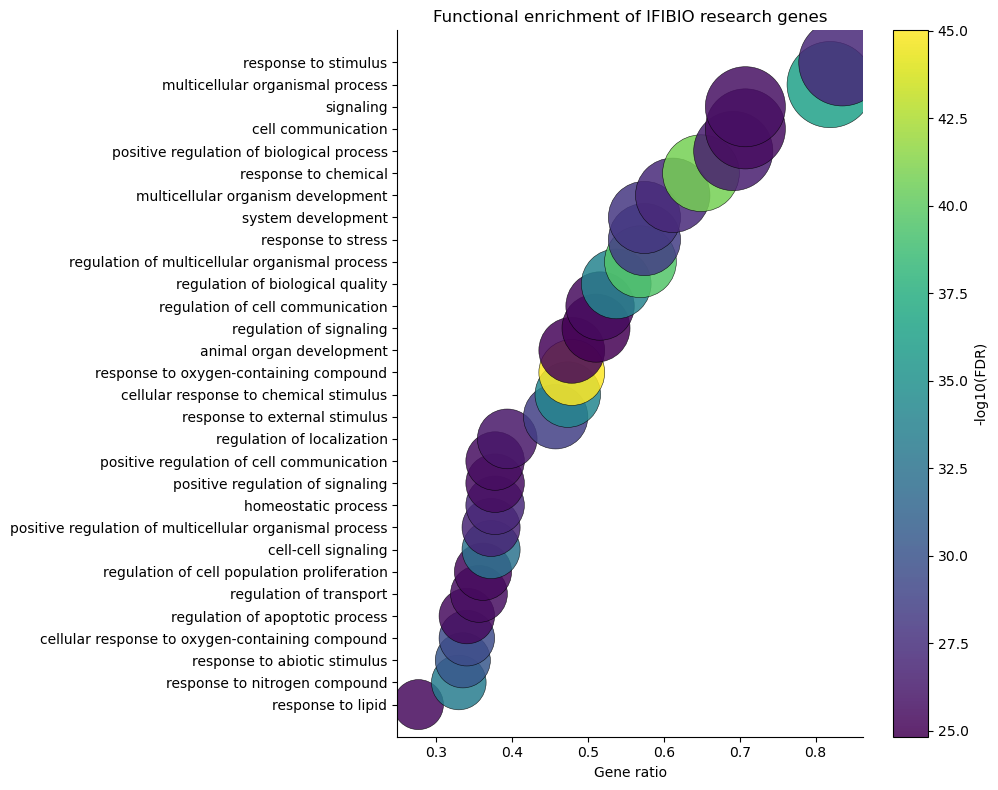

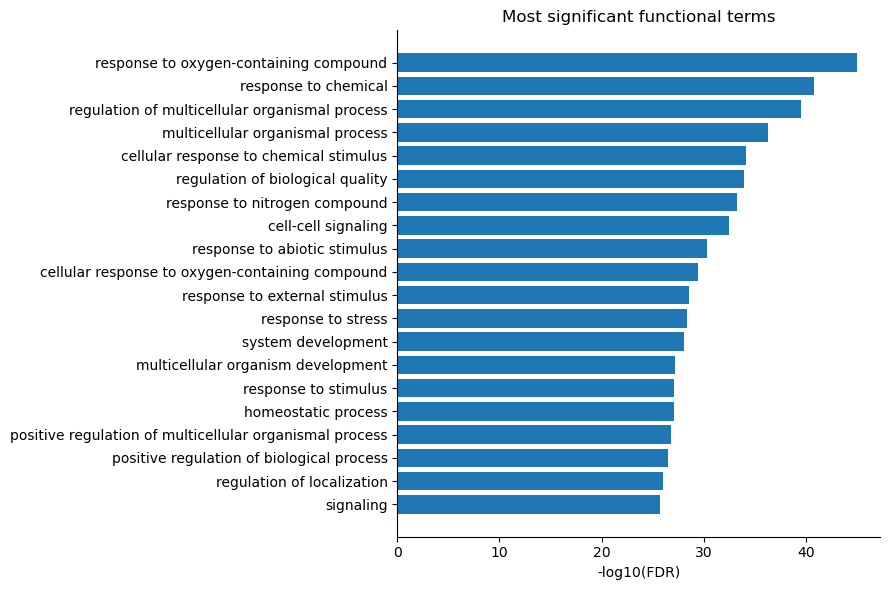

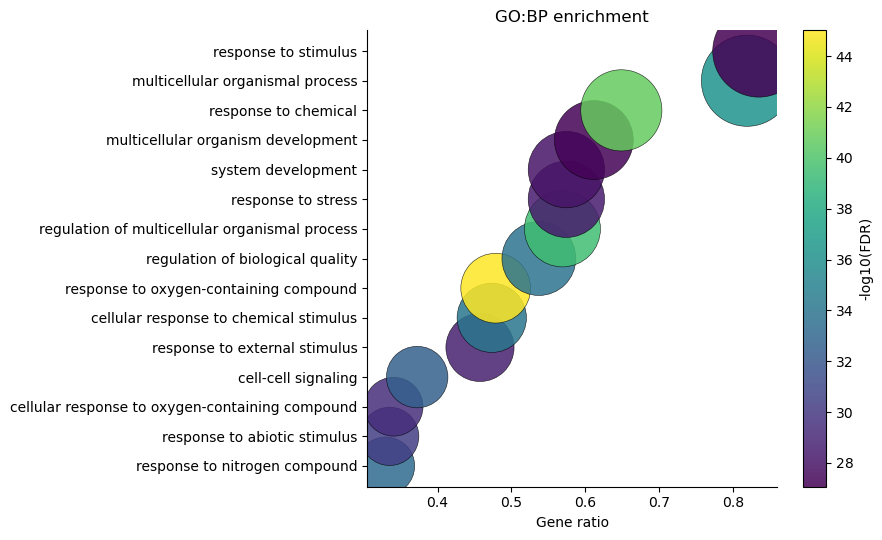

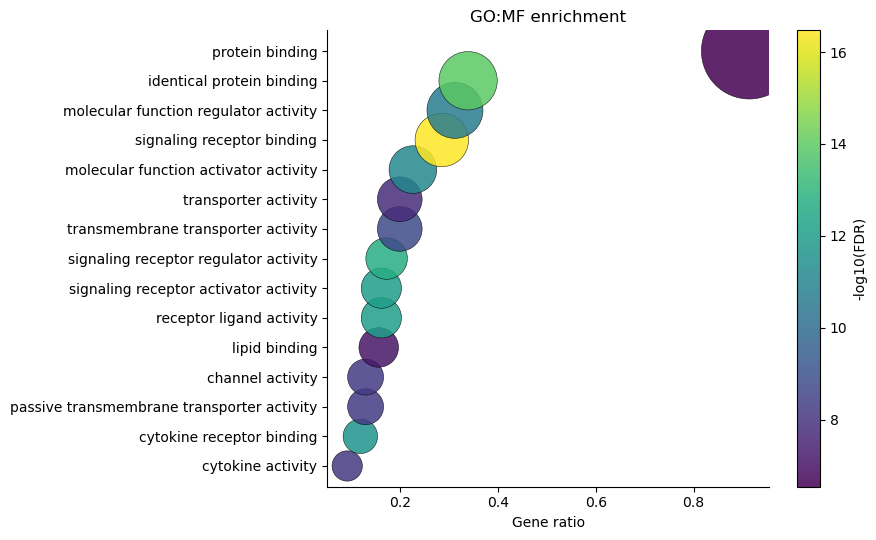

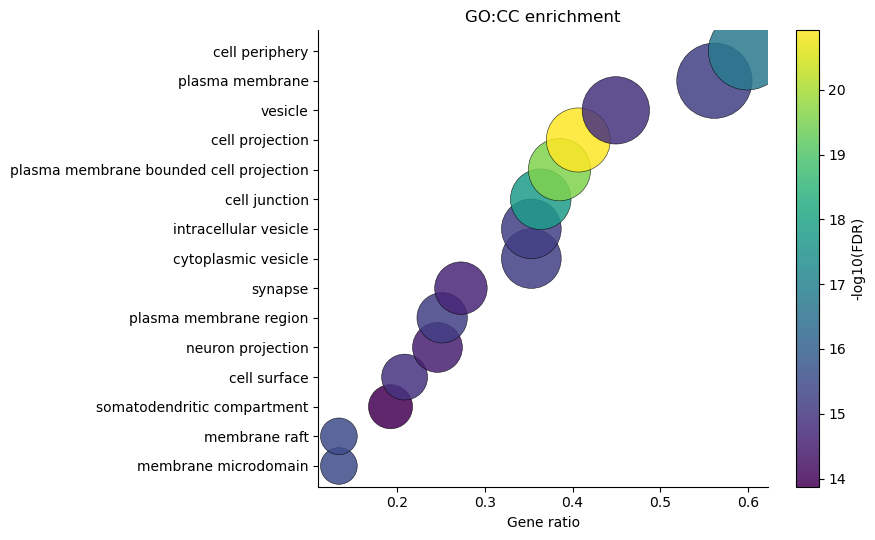

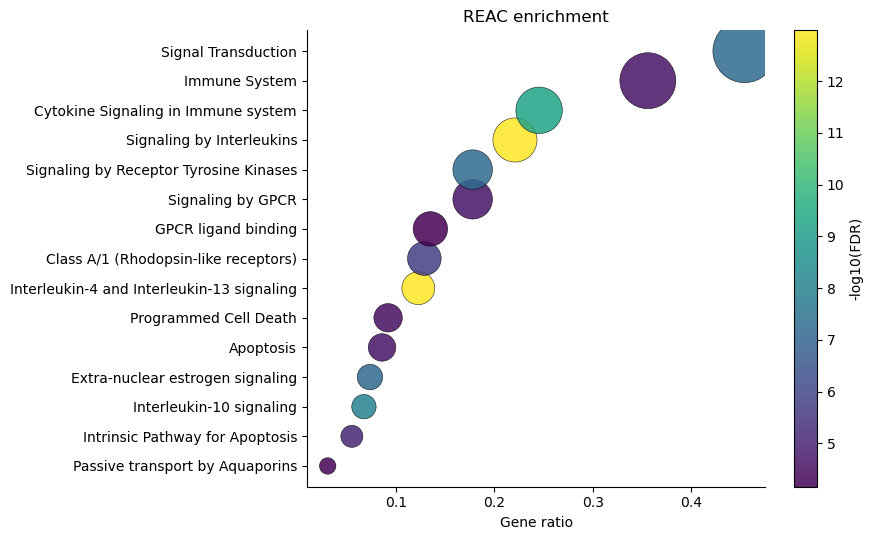

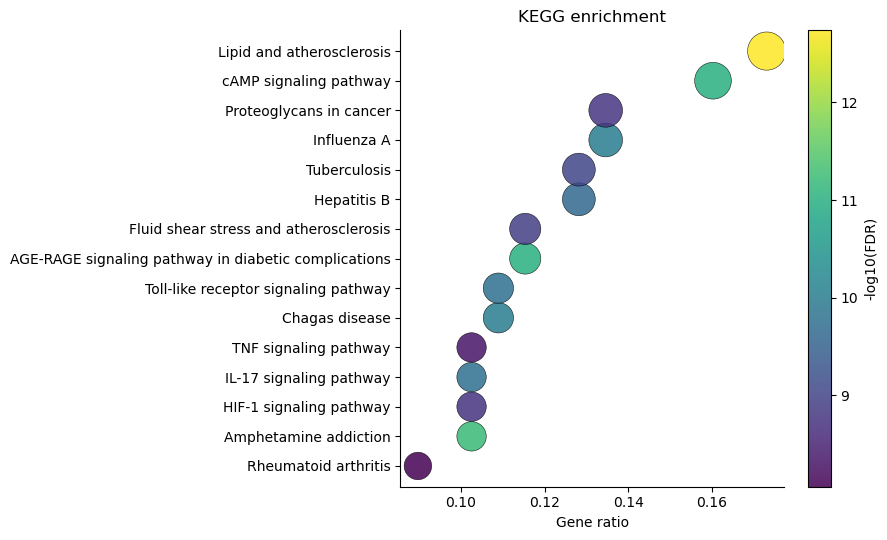

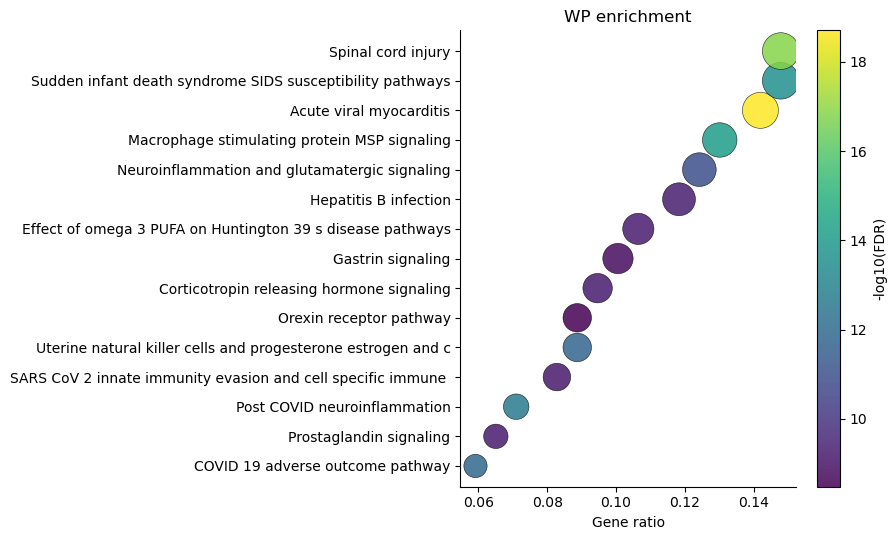

In [27]:
# ============================================================
# FUNCTIONAL ENRICHMENT REAL — g:Profiler
# IFIBIO GeneConcepts
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from gprofiler import GProfiler

# ------------------------------------------------------------
# 1. Lista de genes
# ------------------------------------------------------------

genes_query = (
    gene_concepts["GeneConcept"].dropna().astype(str).str.strip().unique().tolist()
)

print("Genes enviados a g:Profiler:", len(genes_query))


# ------------------------------------------------------------
# 2. Enrichment
# ------------------------------------------------------------

gp = GProfiler(return_dataframe=True)

enrichment = gp.profile(
    organism="hsapiens",
    query=genes_query,
    sources=["GO:BP", "GO:MF", "GO:CC", "REAC", "KEGG", "WP"],
    user_threshold=0.05,
    significance_threshold_method="fdr",
)

print("Términos significativos:", len(enrichment))

display(enrichment.head(30))


# ------------------------------------------------------------
# 3. Variables útiles
# ------------------------------------------------------------

enrichment["minus_log10_p"] = -np.log10(enrichment["p_value"])

enrichment["GeneRatio"] = enrichment["intersection_size"] / enrichment["query_size"]

enrichment["FoldEnrichment"] = enrichment["intersection_size"] / enrichment["term_size"]


# ------------------------------------------------------------
# 4. Resumen por fuente
# ------------------------------------------------------------

source_summary = (
    enrichment.groupby("source")
    .agg(
        Terms=("native", "nunique"),
        Min_p=("p_value", "min"),
        Max_genes=("intersection_size", "max"),
    )
    .sort_values("Terms", ascending=False)
)

print("\nRESULTADOS POR FUENTE")

display(source_summary)


# ------------------------------------------------------------
# 5. DOTPLOT tipo GO enrichment
# ------------------------------------------------------------

top = enrichment.sort_values("p_value").head(30).copy()

top["Label"] = top["name"].astype(str).str.slice(0, 65)

top = top.sort_values("GeneRatio")

fig, ax = plt.subplots(figsize=(10, 8))

sc = ax.scatter(
    top["GeneRatio"],
    top["Label"],
    s=top["intersection_size"] * 25,
    c=top["minus_log10_p"],
    cmap="viridis",
    alpha=0.85,
    edgecolors="black",
    linewidths=0.4,
)

ax.set_xlabel("Gene ratio")
ax.set_ylabel("")
ax.set_title("Functional enrichment of IFIBIO research genes")

cbar = plt.colorbar(sc, ax=ax)

cbar.set_label("-log10(FDR)")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 6. BARPLOT por significancia
# ------------------------------------------------------------

bar = enrichment.sort_values("p_value").head(20).copy()

bar["Label"] = bar["name"].astype(str).str.slice(0, 65)

bar = bar.sort_values("minus_log10_p")

fig, ax = plt.subplots(figsize=(9, 6))

ax.barh(bar["Label"], bar["minus_log10_p"])

ax.set_xlabel("-log10(FDR)")
ax.set_ylabel("")
ax.set_title("Most significant functional terms")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 7. Dotplot separado por fuente
# ------------------------------------------------------------

for source in ["GO:BP", "GO:MF", "GO:CC", "REAC", "KEGG", "WP"]:

    sub = (
        enrichment[enrichment["source"] == source]
        .sort_values("p_value")
        .head(15)
        .copy()
    )

    if len(sub) == 0:
        continue

    sub["Label"] = sub["name"].astype(str).str.slice(0, 60)

    sub = sub.sort_values("GeneRatio")

    fig, ax = plt.subplots(figsize=(9, 5.5))

    sc = ax.scatter(
        sub["GeneRatio"],
        sub["Label"],
        s=sub["intersection_size"] * 28,
        c=sub["minus_log10_p"],
        cmap="viridis",
        alpha=0.85,
        edgecolors="black",
        linewidths=0.4,
    )

    ax.set_xlabel("Gene ratio")
    ax.set_ylabel("")
    ax.set_title(f"{source} enrichment")

    cbar = plt.colorbar(sc, ax=ax)

    cbar.set_label("-log10(FDR)")

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# 8. Guardar resultados
# ------------------------------------------------------------

enrichment.to_csv("ifibio_gprofiler_enrichment.csv", index=False)

source_summary.to_csv("ifibio_gprofiler_source_summary.csv")


In [30]:
# ============================================================
# REEJECUTAR g:Profiler INCLUYENDO GENES DE INTERSECCIÓN
# ============================================================

from gprofiler import GProfiler

gp = GProfiler(return_dataframe=True)

enrichment = gp.profile(
    organism="hsapiens",
    query=genes_query,
    sources=["GO:BP", "GO:MF", "GO:CC", "REAC", "KEGG", "WP"],
    user_threshold=0.05,
    significance_threshold_method="fdr",
    # IMPORTANTE
    no_evidences=False,
)

print(enrichment.columns.tolist())

display(
    enrichment[
        ["source", "native", "name", "p_value", "intersection_size", "intersections"]
    ].head(20)
)


['source', 'native', 'name', 'p_value', 'significant', 'description', 'term_size', 'query_size', 'intersection_size', 'effective_domain_size', 'precision', 'recall', 'query', 'parents', 'intersections', 'evidences']


,source,native,name,p_value,intersection_size,intersections
0,GO:BP,GO:1901700,response to oxygen-containing compound,9.706272e-46,90,"[AQP1, FOS, AQP3, TNF, TRPV4, DRD2, AQP9, CAV1..."
1,GO:BP,GO:0042221,response to chemical,1.572896e-41,122,"[STX2, AQP4, AQP1, FOS, AQP3, TNF, TRPV4, DRD2..."
2,GO:BP,GO:0051239,regulation of multicellular organismal process,3.018903e-40,107,"[AQP1, FOS, AQP3, TNF, TRPV4, DRD2, STX1A, CAV..."
3,GO:BP,GO:0032501,multicellular organismal process,5.110448e-37,154,"[AQP4, AQP1, FOS, AQP3, TNF, TRPV4, DRD2, STX1..."
4,GO:BP,GO:0070887,cellular response to chemical stimulus,7.615188e-35,89,"[STX2, AQP1, FOS, AQP3, TNF, TRPV4, DRD2, AQP9..."
5,GO:BP,GO:0065008,regulation of biological quality,1.230011e-34,101,"[AQP4, AQP1, TARDBP, AQP3, TNF, TRPV4, DRD2, S..."
6,GO:BP,GO:1901698,response to nitrogen compound,5.069047e-34,62,"[AQP1, FOS, TNF, TRPV4, DRD2, AQP9, CAV1, DRD1..."
7,GO:BP,GO:0007267,cell-cell signaling,3.033204e-33,70,"[STX2, AQP1, TARDBP, TNF, TRPV4, DRD2, STX1A, ..."
8,GO:BP,GO:0009628,response to abiotic stimulus,5.065907e-31,63,"[AQP1, FOS, AQP3, TNF, TRPV4, DRD2, CAV1, DRD1..."
9,GO:BP,GO:1901701,cellular response to oxygen-containing compound,3.792134e-30,64,"[AQP1, FOS, TNF, DRD2, AQP9, CAV1, DRD1, AQP2,..."


In [ ]:
# ============================================================
# PREPARAR INTERSECCIONES PARA LOS ANÁLISIS DE RED
# ============================================================

enr = enrichment.copy()

enr = enr[enr["source"].isin(["GO:BP", "REAC", "KEGG", "WP"])].copy()

enr = enr.sort_values("p_value").head(80)

enr["gene_set"] = enr["intersections"].apply(
    lambda x: set(x) if isinstance(x, list) else set()
)

display(
    enr[["source", "name", "p_value", "intersection_size", "intersections"]].head(20)
)


,source,name,p_value,intersection_size,intersections
0,GO:BP,response to oxygen-containing compound,9.706272e-46,90,"[AQP1, FOS, AQP3, TNF, TRPV4, DRD2, AQP9, CAV1..."
1,GO:BP,response to chemical,1.572896e-41,122,"[STX2, AQP4, AQP1, FOS, AQP3, TNF, TRPV4, DRD2..."
2,GO:BP,regulation of multicellular organismal process,3.018903e-40,107,"[AQP1, FOS, AQP3, TNF, TRPV4, DRD2, STX1A, CAV..."
3,GO:BP,multicellular organismal process,5.110448e-37,154,"[AQP4, AQP1, FOS, AQP3, TNF, TRPV4, DRD2, STX1..."
4,GO:BP,cellular response to chemical stimulus,7.615188e-35,89,"[STX2, AQP1, FOS, AQP3, TNF, TRPV4, DRD2, AQP9..."
5,GO:BP,regulation of biological quality,1.230011e-34,101,"[AQP4, AQP1, TARDBP, AQP3, TNF, TRPV4, DRD2, S..."
6,GO:BP,response to nitrogen compound,5.069047e-34,62,"[AQP1, FOS, TNF, TRPV4, DRD2, AQP9, CAV1, DRD1..."
7,GO:BP,cell-cell signaling,3.033204e-33,70,"[STX2, AQP1, TARDBP, TNF, TRPV4, DRD2, STX1A, ..."
8,GO:BP,response to abiotic stimulus,5.065907e-31,63,"[AQP1, FOS, AQP3, TNF, TRPV4, DRD2, CAV1, DRD1..."
9,GO:BP,cellular response to oxygen-containing compound,3.792134e-30,64,"[AQP1, FOS, TNF, DRD2, AQP9, CAV1, DRD1, AQP2,..."


Términos en red: 80
Relaciones: 2635
Módulos funcionales: 3


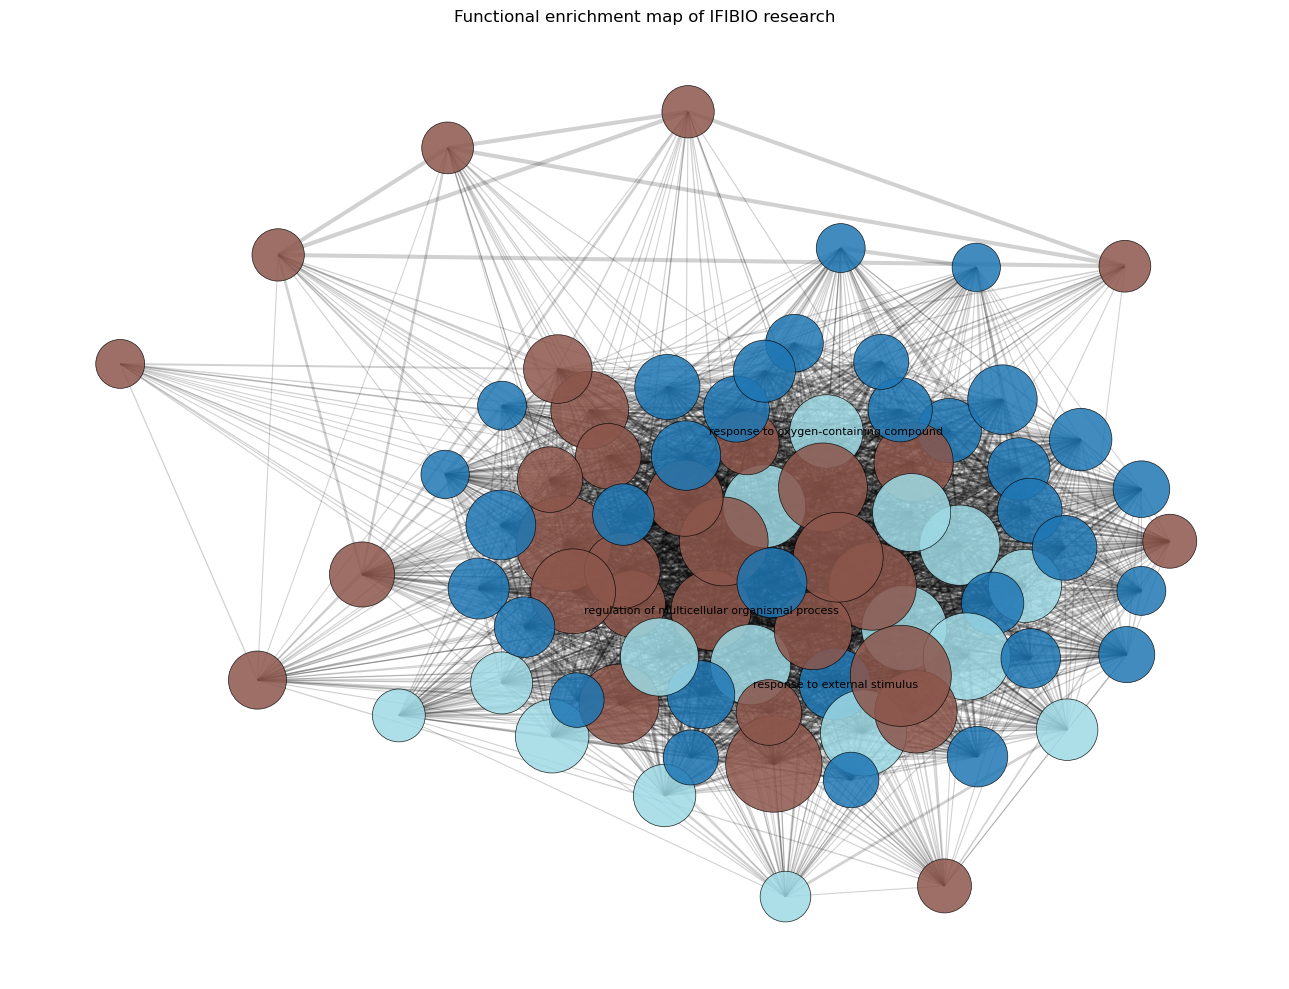

,Module,Representative_term,Source,FDR,N_terms,N_genes,Genes
0,1,response to external stimulus,GO:BP,2.648060e-29,33,154,"[ACE2, ACHE, ADORA2A, AQP1, AQP3, AQP4, ARC, A..."
1,2,regulation of multicellular organismal process,GO:BP,3.018903e-40,31,184,"[ACE2, ACHE, ADORA2A, AQP1, AQP2, AQP3, AQP4, ..."
2,3,response to oxygen-containing compound,GO:BP,9.706272e-46,16,163,"[ACE2, ACHE, ADORA2A, AQP1, AQP2, AQP3, AQP4, ..."


In [ ]:
# ============================================================
# ENRICHMENT MAP
# términos funcionales conectados por genes compartidos
# ============================================================

import ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

# ------------------------------------------------------------
# 1. Preparar términos
# ------------------------------------------------------------

enr = enrichment.copy()

enr = enr[enr["source"].isin(["GO:BP", "REAC", "KEGG", "WP"])].copy()

enr = enr.sort_values("p_value").head(80)


# ------------------------------------------------------------
# 2. Recuperar genes de cada término
# ------------------------------------------------------------


def parse_intersection(x):

    if isinstance(x, list):
        return set(x)

    if pd.isna(x):
        return set()

    try:
        value = ast.literal_eval(str(x))

        if isinstance(value, list):
            return set(value)

    except:
        pass

    return set()


enr["gene_set"] = enr["intersections"].apply(parse_intersection)


# ------------------------------------------------------------
# 3. Construir red por similitud Jaccard
# ------------------------------------------------------------

G = nx.Graph()

for idx, row in enr.iterrows():

    G.add_node(
        idx,
        name=row["name"],
        source=row["source"],
        p=row["p_value"],
        genes=row["intersection_size"],
    )


indices = list(enr.index)

for i in range(len(indices)):

    for j in range(i + 1, len(indices)):

        a = indices[i]
        b = indices[j]

        A = enr.loc[a, "gene_set"]
        B = enr.loc[b, "gene_set"]

        if not A or not B:
            continue

        jaccard = len(A & B) / len(A | B)

        # threshold de similitud
        if jaccard >= 0.25:

            G.add_edge(a, b, weight=jaccard)


# ------------------------------------------------------------
# 4. Eliminar términos aislados
# ------------------------------------------------------------

isolated = list(nx.isolates(G))

G.remove_nodes_from(isolated)

print("Términos en red:", G.number_of_nodes())
print("Relaciones:", G.number_of_edges())


# ------------------------------------------------------------
# 5. Comunidades funcionales
# ------------------------------------------------------------

communities = list(nx.community.greedy_modularity_communities(G, weight="weight"))

community_map = {}

for i, community in enumerate(communities):

    for node in community:
        community_map[node] = i


print("Módulos funcionales:", len(communities))


# ------------------------------------------------------------
# 6. Layout
# ------------------------------------------------------------

pos = nx.spring_layout(G, seed=42, k=0.8, weight="weight")


# ------------------------------------------------------------
# 7. Tamaños
# ------------------------------------------------------------

node_sizes = [100 + G.nodes[n]["genes"] * 30 for n in G.nodes()]


# ------------------------------------------------------------
# 8. Colores por comunidad
# ------------------------------------------------------------

node_colors = [community_map[n] for n in G.nodes()]


# ------------------------------------------------------------
# 9. Plot
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(13, 10))

nx.draw_networkx_edges(
    G, pos, alpha=0.18, width=[G[u][v]["weight"] * 3 for u, v in G.edges()], ax=ax
)

nx.draw_networkx_nodes(
    G,
    pos,
    node_size=node_sizes,
    node_color=node_colors,
    cmap="tab20",
    alpha=0.85,
    linewidths=0.5,
    edgecolors="black",
    ax=ax,
)


# ------------------------------------------------------------
# 10. Etiquetar sólo términos representativos
#     de cada comunidad
# ------------------------------------------------------------

labels = {}

for i, community in enumerate(communities):

    community = list(community)

    representative = min(community, key=lambda n: G.nodes[n]["p"])

    labels[representative] = G.nodes[representative]["name"][:55]


nx.draw_networkx_labels(G, pos, labels=labels, font_size=8, ax=ax)

ax.set_title("Functional enrichment map of IFIBIO research")

ax.axis("off")

plt.tight_layout()
plt.show()


# ============================================================
# TABLA DE MÓDULOS
# ============================================================

module_rows = []

for module, community in enumerate(communities):

    subset = enr.loc[list(community)]

    representative = subset.loc[subset["p_value"].idxmin()]

    all_genes = set()

    for genes in subset["gene_set"]:
        all_genes.update(genes)

    module_rows.append(
        {
            "Module": module + 1,
            "Representative_term": representative["name"],
            "Source": representative["source"],
            "FDR": representative["p_value"],
            "N_terms": len(subset),
            "N_genes": len(all_genes),
            "Genes": sorted(all_genes),
        }
    )


functional_modules = pd.DataFrame(module_rows).sort_values(
    ["N_terms", "N_genes"], ascending=False
)

display(functional_modules)
